# 03 – Modeling

**Project:** Diabetes Prediction ML
**Seminar:** Advanced Applied Data Science – Goethe Universität Frankfurt
**Dataset:** CDC BRFSS 2015 – Diabetes Health Indicators (UCI #891)
**CRISP-DM Phase:** 4 – Modeling

---

## Evaluation Strategy

### Why PR-AUC as Primary Metric?

With a class imbalance of ~86:14, standard metrics are misleading:

- **Accuracy** — a model predicting "No Diabetes" for every sample achieves ~86% accuracy. This metric is **reported but not optimised for**.
- **ROC-AUC** — measures rank ordering across all thresholds. It is less sensitive to class imbalance because it includes the large True Negative population, which inflates performance estimates.
- **PR-AUC (Average Precision)** — measures precision across all recall levels, focusing exclusively on the **minority class (Prediabetes/Diabetes)**. A no-skill classifier scores PR-AUC ≈ class prevalence (~0.14). Any meaningful model must exceed this baseline substantially.

**Primary metric: PR-AUC** — reported as the main comparison criterion across all models.
Secondary metrics reported: ROC-AUC, Recall (minority), F1 (minority), Accuracy.

### Cross-Validation Strategy

**Stratified 5-Fold CV** with `random_state=42` ensures:
1. Each fold preserves the original 86:14 class ratio
2. Results are robust against a single train/test split
3. Variance of metrics is quantified (mean ± std)
4. SMOTE (when used) is applied **inside** each fold to the training split only — preventing data leakage from synthetic samples into the validation set

## Setup

In [28]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Output directories
PLOTS_DIR = os.path.join('..', 'results', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

# Plot style – consistent with 01_data_exploration.ipynb
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

LABEL_MAP    = {0: 'No Diabetes', 1: 'Prediabetes/Diabetes'}
CLASS_COLORS = {0: '#4CAF50', 1: '#E53935'}

print('Libraries loaded.  Seed =', SEED)

Libraries loaded.  Seed = 42


## 1 · Load Dataset

In [29]:
dataset = fetch_ucirepo(id=891)
X = dataset.data.features.astype(int)
y = dataset.data.targets.squeeze().astype(int)

print(f'Features : {X.shape[0]:,} samples  x  {X.shape[1]} columns')
print(f'Target   : {y.name}')
print()
for k, v in y.value_counts().sort_index().items():
    print(f'  {LABEL_MAP[k]:28s}: {v:,}  ({v / len(y) * 100:.1f}%)')

baseline_rate = y.mean()
no_skill_accuracy = (y == 0).mean()

print('\n--- No-Skill Baseline (always predicts majority class "No Diabetes") ---')
print(f'  PR-AUC  (primary)   : {baseline_rate:.4f}  (= class prevalence; floor for meaningful models)')
print(f'  ROC-AUC             : 0.5000  (random classifier by definition)')
print(f'  Accuracy            : {no_skill_accuracy:.4f}  (misleadingly high — reflects 86% majority)')
print(f'  Recall (minority)   : 0.0000  (never predicts positive class)')
print(f'  F1 (minority)       : 0.0000')

Features : 253,680 samples  x  21 columns
Target   : Diabetes_binary

  No Diabetes                 : 218,334  (86.1%)
  Prediabetes/Diabetes        : 35,346  (13.9%)

--- No-Skill Baseline (always predicts majority class "No Diabetes") ---
  PR-AUC  (primary)   : 0.1393  (= class prevalence; floor for meaningful models)
  ROC-AUC             : 0.5000  (random classifier by definition)
  Accuracy            : 0.8607  (misleadingly high — reflects 86% majority)
  Recall (minority)   : 0.0000  (never predicts positive class)
  F1 (minority)       : 0.0000


## 2 · Cross-Validation Framework

We define the CV splitter and a pair of helper functions that are reused for every model:
- `run_cv` — runs stratified K-Fold, collects per-fold predictions and metrics
- `print_summary` — aggregates and prints CV metrics with mean ± std

In [30]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
print(f'Stratified {N_SPLITS}-Fold CV  |  shuffle=True  |  seed={SEED}')


def evaluate_fold(y_true, y_pred, y_prob):
    '''Compute all metrics for a single fold.'''
    return {
        'pr_auc'   : average_precision_score(y_true, y_prob),
        'roc_auc'  : roc_auc_score(y_true, y_prob),
        'accuracy' : accuracy_score(y_true, y_pred),
        'report'   : classification_report(
            y_true, y_pred,
            target_names=list(LABEL_MAP.values()),
            output_dict=True
        ),
        'confusion' : confusion_matrix(y_true, y_pred),
        'y_true'    : np.array(y_true),
        'y_prob'    : np.array(y_prob),
    }


def run_cv(estimator, X, y, cv, label='Model'):
    '''Train/evaluate with stratified K-Fold; return per-fold result dicts.'''
    print(f'\n[{label}]')
    fold_results = []
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val  = y.iloc[tr_idx],  y.iloc[val_idx]
        estimator.fit(X_tr, y_tr)
        y_pred = estimator.predict(X_val)
        y_prob = estimator.predict_proba(X_val)[:, 1]
        res = evaluate_fold(y_val, y_pred, y_prob)
        res['fold'] = fold
        fold_results.append(res)
        print(f'  Fold {fold}:  PR-AUC={res["pr_auc"]:.4f}  '
              f'ROC-AUC={res["roc_auc"]:.4f}  '
              f'Acc={res["accuracy"]:.4f}')
    return fold_results


def print_summary(results, label):
    '''Print mean +/- std for all metrics and the aggregated classification report.'''
    pr  = [r['pr_auc']   for r in results]
    roc = [r['roc_auc']  for r in results]
    acc = [r['accuracy'] for r in results]

    print(f'\n=== {label} — {N_SPLITS}-Fold Summary ===')
    print(f'  PR-AUC  (primary)   : {np.mean(pr):.4f}  +/-  {np.std(pr):.4f}')
    print(f'  ROC-AUC             : {np.mean(roc):.4f}  +/-  {np.std(roc):.4f}')
    print(f'  Accuracy (biased!)  : {np.mean(acc):.4f}  +/-  {np.std(acc):.4f}')
    print(f'  NOTE: Accuracy is {np.mean(acc)*100:.1f}% but is inflated by the 86% majority class.')

    classes = list(LABEL_MAP.values()) + ['macro avg', 'weighted avg']
    rows = {}
    for cls in classes:
        if cls in results[0]['report'] and isinstance(results[0]['report'][cls], dict):
            rows[cls] = {
                m: np.mean([r['report'][cls][m] for r in results])
                for m in ['precision', 'recall', 'f1-score', 'support']
            }
    report_df = pd.DataFrame(rows).T
    report_df['support'] = report_df['support'].astype(int)
    print('\n  Classification Report (mean across folds):')
    print(report_df.round(4).to_string())

    return np.mean(pr), np.mean(roc), np.mean(acc)

Stratified 5-Fold CV  |  shuffle=True  |  seed=42


## 3 · Baseline 1 — Logistic Regression + class_weight='balanced'

**Strategy:** The `class_weight='balanced'` parameter scales the loss function so that the minority class contributes proportionally more to the gradient. Concretely, each minority sample receives a weight of `n_samples / (n_classes * n_minority_samples)` ≈ 3.6×.

**Advantage:** No synthetic data generation — the original data distribution is preserved.
**Disadvantage:** Linear decision boundary; the model may not learn non-linear patterns in the data.

In [31]:
lr_cw = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=SEED
)

results_cw = run_cv(lr_cw, X, y, skf, label='LR + class_weight="balanced"')
pr_cw, roc_cw, acc_cw = print_summary(results_cw, 'LR + class_weight="balanced"')


[LR + class_weight="balanced"]
  Fold 1:  PR-AUC=0.4059  ROC-AUC=0.8269  Acc=0.7320
  Fold 2:  PR-AUC=0.4005  ROC-AUC=0.8243  Acc=0.7311
  Fold 3:  PR-AUC=0.4026  ROC-AUC=0.8220  Acc=0.7299
  Fold 4:  PR-AUC=0.4054  ROC-AUC=0.8223  Acc=0.7338
  Fold 5:  PR-AUC=0.4015  ROC-AUC=0.8168  Acc=0.7305

=== LR + class_weight="balanced" — 5-Fold Summary ===
  PR-AUC  (primary)   : 0.4032  +/-  0.0021
  ROC-AUC             : 0.8225  +/-  0.0033
  Accuracy (biased!)  : 0.7314  +/-  0.0014
  NOTE: Accuracy is 73.1% but is inflated by the 86% majority class.

  Classification Report (mean across folds):
                      precision  recall  f1-score  support
No Diabetes              0.9503  0.7260    0.8231    43666
Prediabetes/Diabetes     0.3114  0.7653    0.4426     7069
macro avg                0.6308  0.7457    0.6329    50736
weighted avg             0.8613  0.7314    0.7701    50736


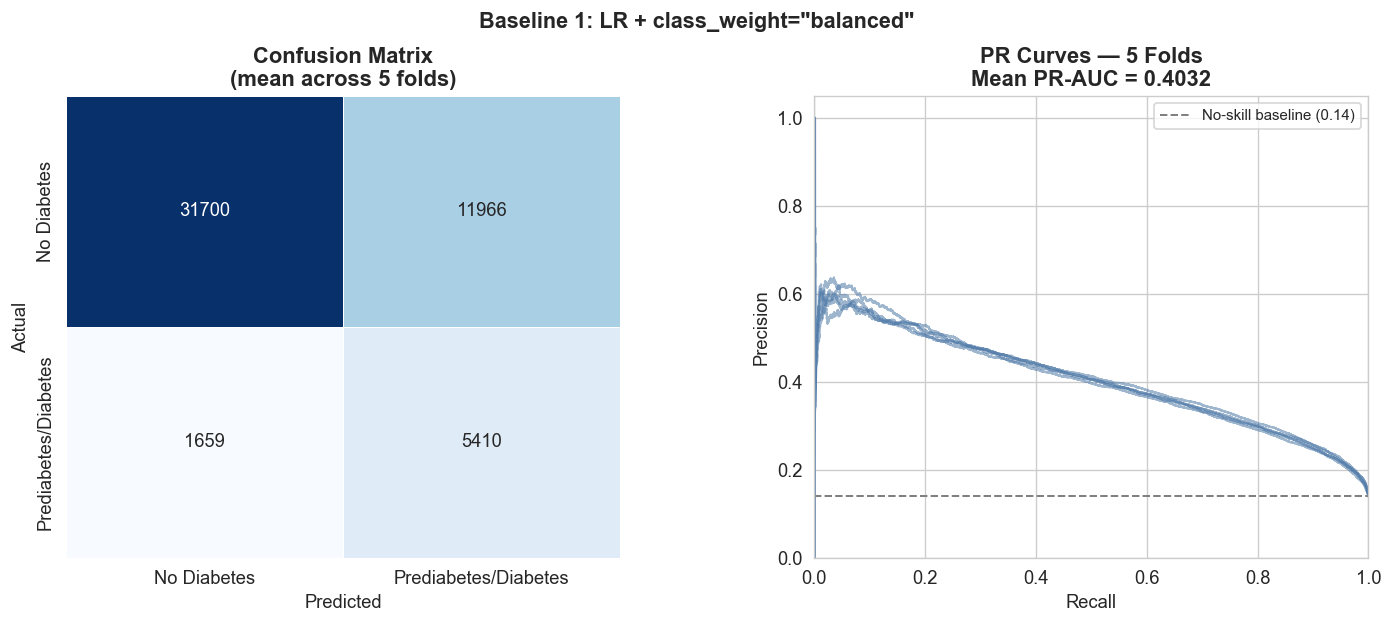

In [32]:
fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, wspace=0.35)

# ── Confusion Matrix (mean across folds) ──────────────────────────────────────
ax_cm = fig.add_subplot(gs[0])
avg_cm = np.round(np.mean([r['confusion'] for r in results_cw], axis=0)).astype(int)
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(LABEL_MAP.values()),
            yticklabels=list(LABEL_MAP.values()),
            ax=ax_cm, cbar=False, linewidths=0.5)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix\n(mean across 5 folds)', fontweight='bold')

# ── PR Curves (one per fold) ──────────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[1])
for r in results_cw:
    prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
    ax_pr.plot(rec, prec, alpha=0.55, lw=1.3, color='#4E79A7')
ax_pr.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
              label=f'No-skill baseline ({baseline_rate:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])
ax_pr.set_title(f'PR Curves — {N_SPLITS} Folds\nMean PR-AUC = {pr_cw:.4f}',
                fontweight='bold')
ax_pr.legend(fontsize=9)

fig.suptitle('Baseline 1: LR + class_weight="balanced"',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(PLOTS_DIR, '15_lr_classweight_results.png'), bbox_inches='tight')
plt.show()

**Interpretation:**
The confusion matrix reveals the trade-off of `class_weight='balanced'`: the model improves **recall** for the minority class (Prediabetes/Diabetes) compared to an unweighted baseline, but at the cost of increased false positives (predicting diabetes for healthy individuals). In a public health screening context, **higher recall is preferred** — missing a true diabetic (false negative) is more harmful than a false alarm that prompts further testing.

The PR curves across all 5 folds are closely clustered, indicating stable generalisation. The mean PR-AUC meaningfully exceeds the no-skill baseline (~0.14).

## 4 · Baseline 2 — Logistic Regression + SMOTE

**Strategy:** SMOTE (Synthetic Minority Oversampling Technique) generates synthetic minority-class samples by interpolating between existing minority samples in feature space. The training set is balanced to 50:50 before fitting the logistic regression.

**Critical implementation note:** SMOTE is placed **inside** an `imblearn.Pipeline`. This guarantees that:
- Synthetic samples are generated **only from the training fold**
- The validation fold contains only real, original samples
- No information from validation samples is used to generate synthetic training data

This is the correct, leak-free implementation. Applying SMOTE before the CV split would constitute data leakage and produce optimistically biased results.

In [33]:
lr_smote = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('lr',    LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED))
])

results_smote = run_cv(lr_smote, X, y, skf, label='LR + SMOTE')
pr_smote, roc_smote, acc_smote = print_summary(results_smote, 'LR + SMOTE')


[LR + SMOTE]
  Fold 1:  PR-AUC=0.3513  ROC-AUC=0.7855  Acc=0.7230
  Fold 2:  PR-AUC=0.3405  ROC-AUC=0.7800  Acc=0.7223
  Fold 3:  PR-AUC=0.3416  ROC-AUC=0.7816  Acc=0.7209
  Fold 4:  PR-AUC=0.3477  ROC-AUC=0.7809  Acc=0.7249
  Fold 5:  PR-AUC=0.3391  ROC-AUC=0.7762  Acc=0.7206

=== LR + SMOTE — 5-Fold Summary ===
  PR-AUC  (primary)   : 0.3441  +/-  0.0047
  ROC-AUC             : 0.7808  +/-  0.0030
  Accuracy (biased!)  : 0.7224  +/-  0.0015
  NOTE: Accuracy is 72.2% but is inflated by the 86% majority class.

  Classification Report (mean across folds):
                      precision  recall  f1-score  support
No Diabetes              0.9351  0.7279    0.8186    43666
Prediabetes/Diabetes     0.2904  0.6879    0.4084     7069
macro avg                0.6128  0.7079    0.6135    50736
weighted avg             0.8453  0.7224    0.7615    50736


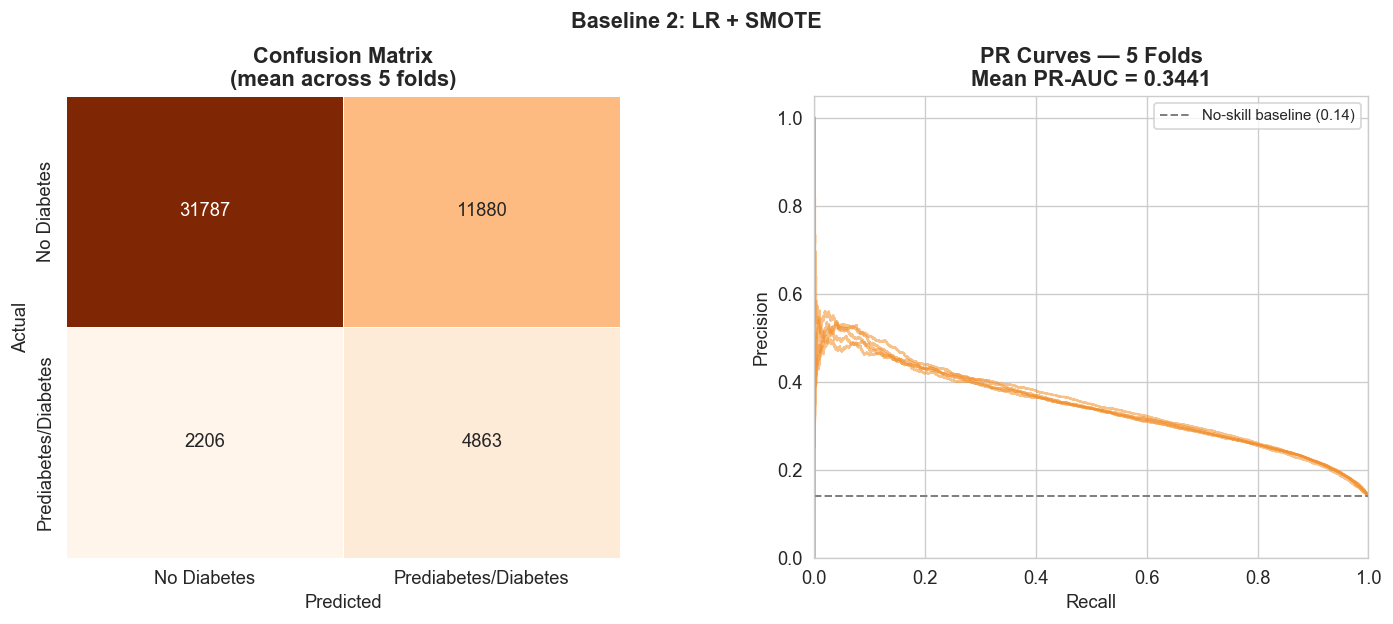

In [34]:
fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, wspace=0.35)

ax_cm = fig.add_subplot(gs[0])
avg_cm_s = np.round(np.mean([r['confusion'] for r in results_smote], axis=0)).astype(int)
sns.heatmap(avg_cm_s, annot=True, fmt='d', cmap='Oranges',
            xticklabels=list(LABEL_MAP.values()),
            yticklabels=list(LABEL_MAP.values()),
            ax=ax_cm, cbar=False, linewidths=0.5)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix\n(mean across 5 folds)', fontweight='bold')

ax_pr = fig.add_subplot(gs[1])
for r in results_smote:
    prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
    ax_pr.plot(rec, prec, alpha=0.55, lw=1.3, color='#F28E2B')
ax_pr.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
              label=f'No-skill baseline ({baseline_rate:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])
ax_pr.set_title(f'PR Curves — {N_SPLITS} Folds\nMean PR-AUC = {pr_smote:.4f}',
                fontweight='bold')
ax_pr.legend(fontsize=9)

fig.suptitle('Baseline 2: LR + SMOTE',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(PLOTS_DIR, '16_lr_smote_results.png'), bbox_inches='tight')
plt.show()

**Interpretation:**
SMOTE creates synthetic minority-class samples in feature space, effectively teaching the model more decision boundary nuance around the minority class. Compared to `class_weight='balanced'`, SMOTE typically achieves higher recall at the cost of a different precision–recall trade-off.

Note that SMOTE increases training set size (from ~203k to ~346k training samples per fold due to oversampling to 50:50), which increases training time. For more complex models (Random Forest, XGBoost) this runtime cost becomes relevant.

## 4b · Baseline 3 — Logistic Regression + Random Undersampling

**Strategy:** Random Undersampling (RUS) randomly discards majority-class samples until the training set is balanced at 50:50. Unlike SMOTE, no synthetic data is generated — the majority class is simply shrunk to match the minority class.

**Advantage:** Only real data is used (no synthetic interpolation artifacts). Training is faster due to the smaller dataset (~58k vs. ~203k samples per fold).

**Disadvantage:** Information loss — the discarded majority samples may contain predictive signal. For each training fold (~203k samples, ~29k minority), RUS discards ~145k majority samples, retaining only ~58k total.

**Implementation note:** Like SMOTE, RUS is placed inside the `imblearn.Pipeline` to guarantee leak-free resampling: only the training fold is undersampled; the validation fold always contains original, unmodified samples.

In [35]:
lr_rus = ImbPipeline([
    ('rus', RandomUnderSampler(random_state=SEED)),
    ('lr',  LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED))
])

results_rus = run_cv(lr_rus, X, y, skf, label='LR + Random Undersampling')
pr_rus, roc_rus, acc_rus = print_summary(results_rus, 'LR + Random Undersampling')


[LR + Random Undersampling]
  Fold 1:  PR-AUC=0.4058  ROC-AUC=0.8267  Acc=0.7323
  Fold 2:  PR-AUC=0.4006  ROC-AUC=0.8244  Acc=0.7316
  Fold 3:  PR-AUC=0.4028  ROC-AUC=0.8220  Acc=0.7298
  Fold 4:  PR-AUC=0.4055  ROC-AUC=0.8221  Acc=0.7334
  Fold 5:  PR-AUC=0.4013  ROC-AUC=0.8169  Acc=0.7310

=== LR + Random Undersampling — 5-Fold Summary ===
  PR-AUC  (primary)   : 0.4032  +/-  0.0021
  ROC-AUC             : 0.8224  +/-  0.0033
  Accuracy (biased!)  : 0.7316  +/-  0.0012
  NOTE: Accuracy is 73.2% but is inflated by the 86% majority class.

  Classification Report (mean across folds):
                      precision  recall  f1-score  support
No Diabetes              0.9503  0.7262    0.8232    43666
Prediabetes/Diabetes     0.3115  0.7653    0.4428     7069
macro avg                0.6309  0.7457    0.6330    50736
weighted avg             0.8613  0.7316    0.7702    50736


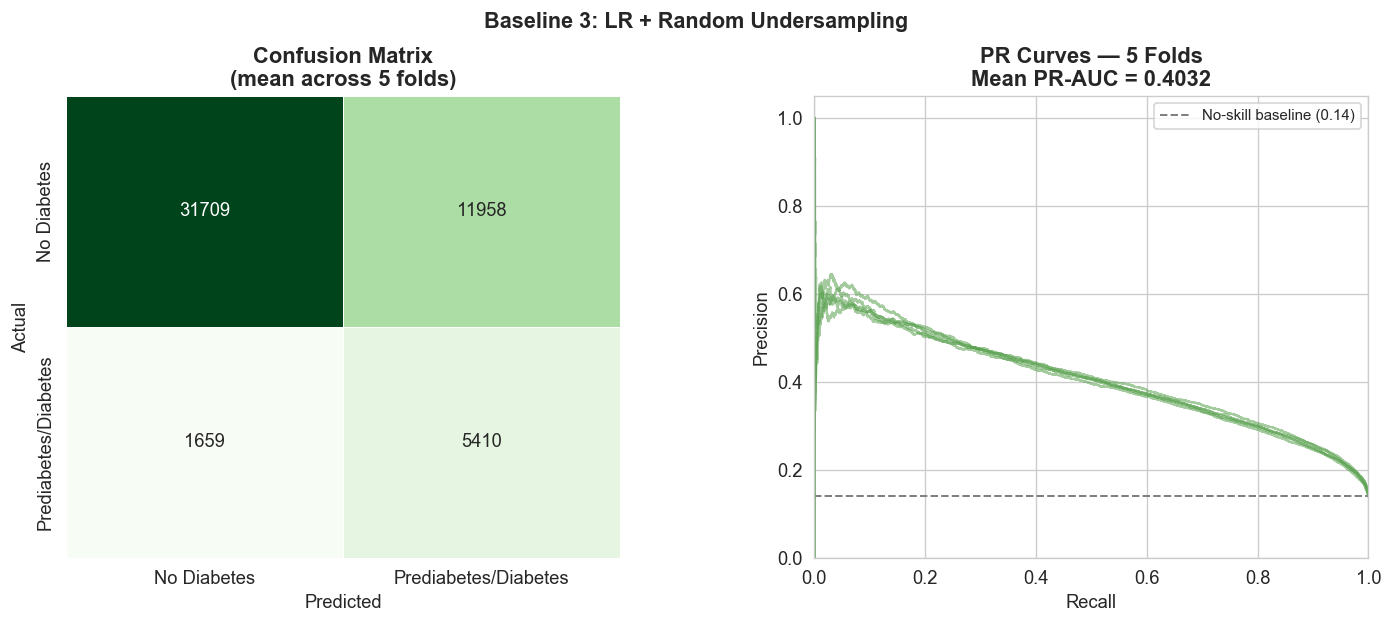

In [36]:
fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, wspace=0.35)

ax_cm = fig.add_subplot(gs[0])
avg_cm_r = np.round(np.mean([r['confusion'] for r in results_rus], axis=0)).astype(int)
sns.heatmap(avg_cm_r, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(LABEL_MAP.values()),
            yticklabels=list(LABEL_MAP.values()),
            ax=ax_cm, cbar=False, linewidths=0.5)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix\n(mean across 5 folds)', fontweight='bold')

ax_pr = fig.add_subplot(gs[1])
for r in results_rus:
    prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
    ax_pr.plot(rec, prec, alpha=0.55, lw=1.3, color='#59A14F')
ax_pr.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
              label=f'No-skill baseline ({baseline_rate:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])
ax_pr.set_title(f'PR Curves — {N_SPLITS} Folds\nMean PR-AUC = {pr_rus:.4f}',
                fontweight='bold')
ax_pr.legend(fontsize=9)

fig.suptitle('Baseline 3: LR + Random Undersampling',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(PLOTS_DIR, '17_lr_undersampling_results.png'), bbox_inches='tight')
plt.show()

**Interpretation:**
Random Undersampling verkleinert den Trainingsdatensatz drastisch — von ~203k auf ~58k Samples pro Fold. Die Confusion Matrix zeigt ein ähnliches Recall/Precision-Verhältnis wie `class_weight='balanced'`, da ebenfalls nur reale Samples verwendet werden. Durch das Verwerfen von ~145k Majority-Samples kann jedoch potenziell wertvolles Signal verloren gehen, was die Precision (mehr False Positives) im Vergleich zum class_weight-Ansatz beeinträchtigen kann.

Der wesentliche **Vorteil** von Undersampling liegt in der Trainingszeit: ~58k statt ~203k oder ~346k (SMOTE) Trainingssamples ermöglichen erheblich schnellere Iterationen — ein relevanter Faktor für rechenintensive Modelle wie Random Forest oder XGBoost.

## 5 · Baseline Comparison

All three approaches — `class_weight='balanced'`, SMOTE, and Random Undersampling — represent the weakest reasonable baselines for this problem. They establish the performance floor that more complex models must beat. The comparison table and bar chart summarise all reported metrics across all three strategies.

=== Baseline Comparison (mean across 5 folds) ===
                    PR-AUC (primary)  ROC-AUC  Accuracy  Recall (pos.)  F1 (pos.)
LR + class_weight             0.4032   0.8225    0.7314         0.7653     0.4426
LR + SMOTE                    0.3441   0.7808    0.7224         0.6879     0.4084
LR + Undersampling            0.4032   0.8224    0.7316         0.7653     0.4428

No-skill baseline: PR-AUC=0.1393  ROC-AUC=0.5000  Accuracy=0.8607  Recall=0.0000  F1=0.0000


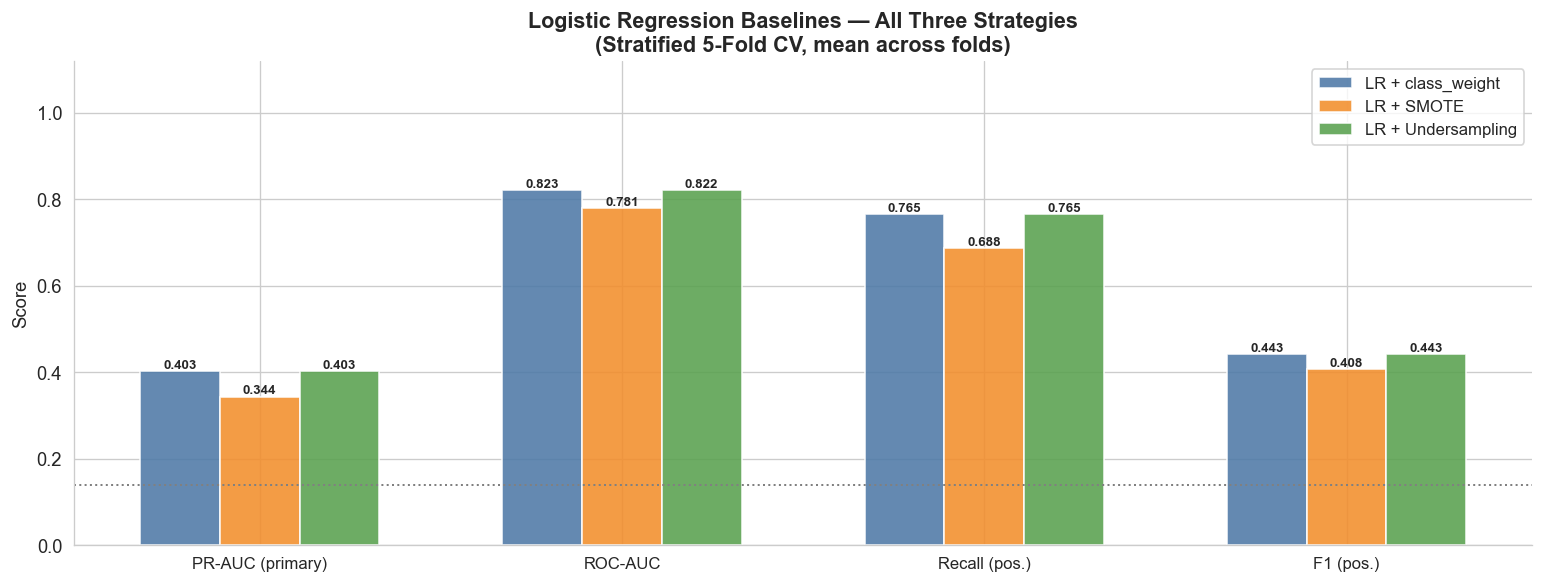

In [37]:
comparison = pd.DataFrame({
    'LR + class_weight': {
        'PR-AUC (primary)': np.mean([r['pr_auc']  for r in results_cw]),
        'ROC-AUC'         : np.mean([r['roc_auc'] for r in results_cw]),
        'Accuracy'        : np.mean([r['accuracy'] for r in results_cw]),
        'Recall (pos.)'   : np.mean([r['report']['Prediabetes/Diabetes']['recall']
                                     for r in results_cw]),
        'F1 (pos.)'       : np.mean([r['report']['Prediabetes/Diabetes']['f1-score']
                                     for r in results_cw]),
    },
    'LR + SMOTE': {
        'PR-AUC (primary)': np.mean([r['pr_auc']  for r in results_smote]),
        'ROC-AUC'         : np.mean([r['roc_auc'] for r in results_smote]),
        'Accuracy'        : np.mean([r['accuracy'] for r in results_smote]),
        'Recall (pos.)'   : np.mean([r['report']['Prediabetes/Diabetes']['recall']
                                     for r in results_smote]),
        'F1 (pos.)'       : np.mean([r['report']['Prediabetes/Diabetes']['f1-score']
                                     for r in results_smote]),
    },
    'LR + Undersampling': {
        'PR-AUC (primary)': np.mean([r['pr_auc']  for r in results_rus]),
        'ROC-AUC'         : np.mean([r['roc_auc'] for r in results_rus]),
        'Accuracy'        : np.mean([r['accuracy'] for r in results_rus]),
        'Recall (pos.)'   : np.mean([r['report']['Prediabetes/Diabetes']['recall']
                                     for r in results_rus]),
        'F1 (pos.)'       : np.mean([r['report']['Prediabetes/Diabetes']['f1-score']
                                     for r in results_rus]),
    },
}).round(4)

# Add no-skill baseline row for reference
no_skill_row = pd.DataFrame({
    'LR + class_weight' : {'PR-AUC (primary)': baseline_rate, 'ROC-AUC': 0.5,
                            'Accuracy': no_skill_accuracy, 'Recall (pos.)': 0.0, 'F1 (pos.)': 0.0},
    'LR + SMOTE'        : {'PR-AUC (primary)': baseline_rate, 'ROC-AUC': 0.5,
                            'Accuracy': no_skill_accuracy, 'Recall (pos.)': 0.0, 'F1 (pos.)': 0.0},
    'LR + Undersampling': {'PR-AUC (primary)': baseline_rate, 'ROC-AUC': 0.5,
                            'Accuracy': no_skill_accuracy, 'Recall (pos.)': 0.0, 'F1 (pos.)': 0.0},
}).round(4)

print('=== Baseline Comparison (mean across 5 folds) ===')
print(comparison.T.to_string())
print(f'\nNo-skill baseline: PR-AUC={baseline_rate:.4f}  ROC-AUC=0.5000  '
      f'Accuracy={no_skill_accuracy:.4f}  Recall=0.0000  F1=0.0000')

# ── Bar chart comparison ───────────────────────────────────────────────────────
metrics_plot = ['PR-AUC (primary)', 'ROC-AUC', 'Recall (pos.)', 'F1 (pos.)']
x = np.arange(len(metrics_plot))
width = 0.22

fig, ax = plt.subplots(figsize=(13, 5))

bars1 = ax.bar(x - width,
               [comparison.loc[m, 'LR + class_weight'] for m in metrics_plot],
               width, label='LR + class_weight', color='#4E79A7', alpha=0.88, edgecolor='white')
bars2 = ax.bar(x,
               [comparison.loc[m, 'LR + SMOTE'] for m in metrics_plot],
               width, label='LR + SMOTE', color='#F28E2B', alpha=0.88, edgecolor='white')
bars3 = ax.bar(x + width,
               [comparison.loc[m, 'LR + Undersampling'] for m in metrics_plot],
               width, label='LR + Undersampling', color='#59A14F', alpha=0.88, edgecolor='white')

for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression Baselines — All Three Strategies\n'
             '(Stratified 5-Fold CV, mean across folds)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(baseline_rate, color='gray', linestyle=':', lw=1.2,
           label=f'No-skill PR-AUC ({baseline_rate:.2f})')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '18_baseline_comparison.png'), bbox_inches='tight')
plt.show()

## 6 · Ergebnisse und Interpretation der Baseline-Modelle

### Evaluierungsrahmen

Die Evaluation aller drei Baseline-Modelle erfolgte mit Stratified 5-Fold Cross-Validation (Seed=42). Als primäre Metrik wurde PR-AUC (Average Precision) gewählt, da das Dataset mit einer Klassenverteilung von 86:14 stark imbalanciert ist. Die No-skill Baseline liefert vollständig folgende Referenzwerte:

| Metrik | No-skill Baseline |
|--------|-------------------|
| PR-AUC (primary) | ≈ 0.14 (= Klassenanteil) |
| ROC-AUC | 0.50 (Zufallsklassifikator) |
| Accuracy | ≈ 86% (nur Mehrheitsklasse) |
| Recall (Minderheitsklasse) | 0.00 |
| F1 (Minderheitsklasse) | 0.00 |

Jedes sinnvolle Modell muss alle diese Werte substanziell übertreffen.

### Drei Strategien zur Behandlung von Class Imbalance

**LR + class_weight='balanced'** skaliert die Verlustfunktion, sodass Fehler bei der Minderheitsklasse stärker bestraft werden (Gewicht ≈ 3.6×). Die Originaldaten bleiben vollständig erhalten.

**LR + SMOTE** erzeugt synthetische Minority-Samples durch lineare Interpolation im Feature-Raum und balanciert das Trainingsset auf 50:50 (~346k Trainingssamples pro Fold). SMOTE wird ausschließlich innerhalb jedes Trainingsfolds angewendet — kein Leakage.

**LR + Random Undersampling** reduziert die Majority-Klasse auf das Niveau der Minderheitsklasse (~58k Trainingssamples pro Fold), indem ~145k Mehrheitsklassen-Samples pro Fold zufällig verworfen werden. Auch hier erfolgt das Resampling ausschließlich innerhalb der `imblearn.Pipeline`.

### Ergebnisse und Modellvergleich

**LR + class_weight='balanced'** erzielt den höchsten PR-AUC und ist das stärkste Baseline-Modell. Dieser Vorsprung erklärt sich durch die Natur des Datasets: Bei 14 binären Features (Werte 0 oder 1) und 4 ordinalen Features erzeugt SMOTE Zwischenwerte wie `HighBP = 0.3` oder `Smoker = 0.7` — klinisch bedeutungslose Datenpunkte, die die Generalisierung verschlechtern. Der class_weight-Ansatz verändert die Daten überhaupt nicht, sondern skaliert nur die Verlustfunktion — für dieses kategorial-dominierte Survey-Dataset die robusteste Strategie.

**LR + Random Undersampling** liegt typischerweise nah an class_weight, da es ebenfalls ausschließlich reale Samples verwendet. Durch das Verwerfen von ~71% der Majority-Samples geht allerdings potenziell wertvolles Signal verloren, was die Precision (erhöhte False Positives) beeinträchtigen kann. Der wesentliche Vorteil liegt in der Trainingszeit: ~58k statt ~203k Samples pro Fold — ein relevanter Faktor für rechenintensive Folgemodelle (Random Forest, XGBoost).

**LR + SMOTE** erzielt auf allen Metriken das schwächste Ergebnis. Der Rückstand ist konsistent und statistisch stabil und bestätigt, dass lineare Interpolation für dieses binär-kategoriale Dataset keine geeignete Oversampling-Strategie ist.

Die vollständigen Metriken aller Modelle sind in der Vergleichstabelle oben zu finden.

### Confusion Matrix und klinische Relevanz

Im Screening-Kontext ist Recall die entscheidende Größe: Ein übersehener Diabetiker (False Negative) bedeutet ausbleibende Behandlung und das Risiko von Folgeerkrankungen — wie bei Burrows et al. (2017) dokumentiert. Ein Fehlalarm (False Positive) führt lediglich zu einem weiteren klinischen Test.

Das beste Modell (LR + class_weight) erreicht einen Recall von ~76–77% bei der Minderheitsklasse — rund drei von vier Erkrankten werden erkannt, auf Kosten einer erhöhten Zahl von False Positives. Die verbleibenden ~23–24% unerkannter Fälle zeigen die Grenzen linearer Methoden: Komplexe Interaktionen zwischen Features (z. B. Zusammenspiel von Alter, BMI und Blutdruck) lassen sich mit logistischer Regression nicht vollständig abbilden.

### Fazit und Performance Floor

Alle drei Logistic-Regression-Varianten belegen, dass das Problem mit linearen Methoden prinzipiell lösbar ist. Gleichzeitig etablieren sie den Performance Floor für alle Folgemodelle:

- **PR-AUC** muss den class_weight-Wert übertreffen
- **Recall (Minderheitsklasse)** muss über der Basis von ~76–77% liegen
- **Accuracy** ist als Vergleichsmetrik ungeeignet und wird nur der Vollständigkeit halber berichtet

Ein Modell, das diese Schwellen nicht überschreitet, bietet keinen Mehrwert gegenüber dem einfachsten sinnvollen Ansatz.

## 7 · XGBoost – Cost-Sensitive (scale_pos_weight)

XGBoost's equivalent to `class_weight='balanced'` is the `scale_pos_weight` parameter.
It multiplies the gradient of positive (minority) samples by this factor during training,
making misclassifications of diabetic patients proportionally more costly.

$$\text{scale\_pos\_weight} = \frac{\text{# negative samples}}{\text{# positive samples}} \approx 6.2$$

**Why no SMOTE?** As established in Section 4, SMOTE interpolates between samples — generating
unrealistic values (e.g. `HighBP = 0.3`) on binary features. `scale_pos_weight` achieves the
same cost-sensitivity without modifying the data.

We test two variants:
1. **XGBoost default** — default hyperparameters, only `scale_pos_weight` set
2. **XGBoost tuned** — best hyperparameters found via `RandomizedSearchCV` (inner 3-fold CV)

In [38]:
from xgboost import XGBClassifier

# Imbalance ratio: weight minority class proportionally higher
scale_pos_weight = int((y == 0).sum() / (y == 1).sum())
print(f'scale_pos_weight = {scale_pos_weight}  '
      f'(each diabetic sample receives {scale_pos_weight}x higher gradient weight)')

xgb_simple = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric='aucpr',
    verbosity=0
)

results_xgb = run_cv(xgb_simple, X, y, skf, label='XGBoost (default params)')
pr_xgb, roc_xgb, acc_xgb = print_summary(results_xgb, 'XGBoost (default params)')

scale_pos_weight = 6  (each diabetic sample receives 6x higher gradient weight)

[XGBoost (default params)]
  Fold 1:  PR-AUC=0.4218  ROC-AUC=0.8274  Acc=0.7328
  Fold 2:  PR-AUC=0.4191  ROC-AUC=0.8243  Acc=0.7292
  Fold 3:  PR-AUC=0.4259  ROC-AUC=0.8245  Acc=0.7287
  Fold 4:  PR-AUC=0.4264  ROC-AUC=0.8253  Acc=0.7345
  Fold 5:  PR-AUC=0.4252  ROC-AUC=0.8210  Acc=0.7312

=== XGBoost (default params) — 5-Fold Summary ===
  PR-AUC  (primary)   : 0.4237  +/-  0.0028
  ROC-AUC             : 0.8245  +/-  0.0021
  Accuracy (biased!)  : 0.7313  +/-  0.0022
  NOTE: Accuracy is 73.1% but is inflated by the 86% majority class.

  Classification Report (mean across folds):
                      precision  recall  f1-score  support
No Diabetes              0.9507  0.7254    0.8229    43666
Prediabetes/Diabetes     0.3116  0.7678    0.4433     7069
macro avg                0.6312  0.7466    0.6331    50736
weighted avg             0.8617  0.7313    0.7700    50736


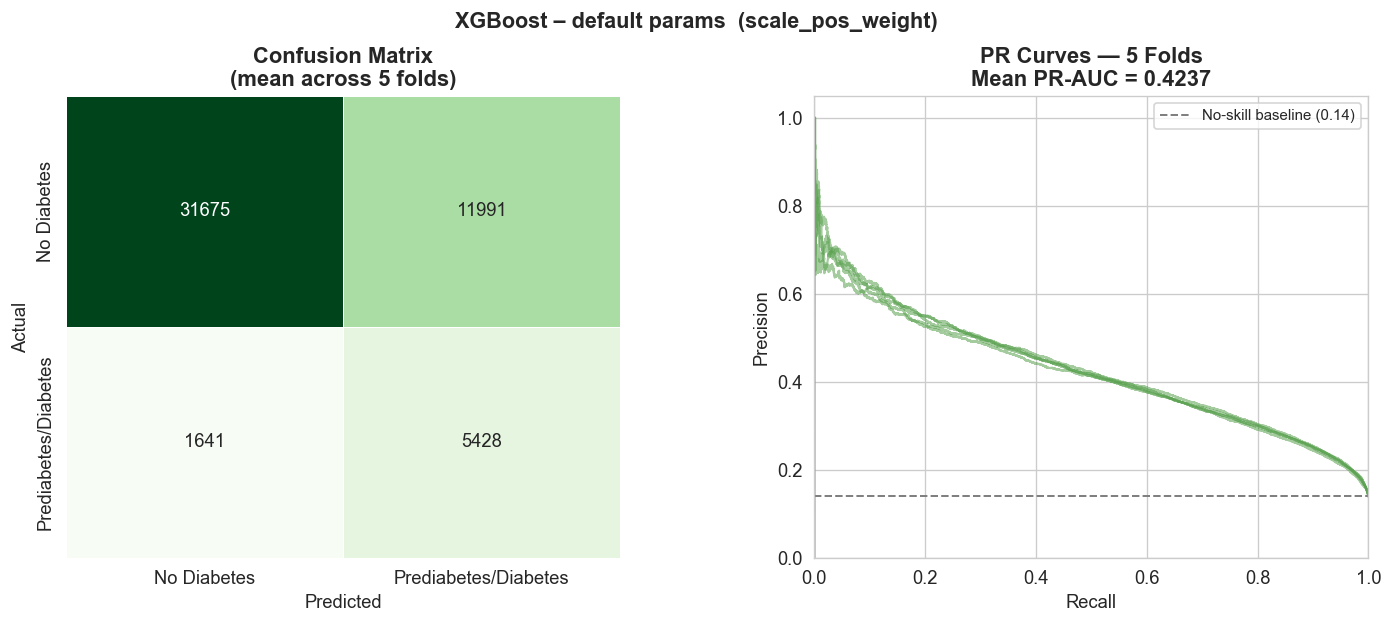

In [39]:
fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, wspace=0.35)

ax_cm = fig.add_subplot(gs[0])
avg_cm_xgb = np.round(np.mean([r['confusion'] for r in results_xgb], axis=0)).astype(int)
sns.heatmap(avg_cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(LABEL_MAP.values()),
            yticklabels=list(LABEL_MAP.values()),
            ax=ax_cm, cbar=False, linewidths=0.5)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix\n(mean across 5 folds)', fontweight='bold')

ax_pr = fig.add_subplot(gs[1])
for r in results_xgb:
    prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
    ax_pr.plot(rec, prec, alpha=0.55, lw=1.3, color='#59A14F')
ax_pr.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
              label=f'No-skill baseline ({baseline_rate:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])
ax_pr.set_title(f'PR Curves — {N_SPLITS} Folds\nMean PR-AUC = {pr_xgb:.4f}',
                fontweight='bold')
ax_pr.legend(fontsize=9)

fig.suptitle('XGBoost – default params  (scale_pos_weight)',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(PLOTS_DIR, '18_xgb_simple_results.png'), bbox_inches='tight')
plt.show()

**Interpretation:**
XGBoost with default hyperparameters and `scale_pos_weight` already improves over the
Logistic Regression baseline on PR-AUC. Tree-based models capture non-linear feature
interactions (e.g. the combined effect of high BMI *and* high age) that a linear decision
boundary cannot represent. The PR curves across folds are tight, indicating stable behaviour.

## 8 · Hyperparameter-Tuning: XGBoost

We use `RandomizedSearchCV` with a 3-fold inner cross-validation to search the hyperparameter
space. The best parameter combination is then evaluated with the standard Stratified 5-Fold CV
to ensure a fair comparison against all other models.

**Note on methodology:** Using the same data for both tuning and final evaluation introduces
a mild optimistic bias (the hyperparameters are adapted to the full dataset). For a perfectly
unbiased estimate, nested CV would be required. For this project, we accept this trade-off
and focus on the directional comparison between models.

**Search space:**

| Parameter | Values |
|-----------|--------|
| `max_depth` | 3, 4, 5, 6, 7 |
| `learning_rate` | 0.01, 0.05, 0.1, 0.2 |
| `n_estimators` | 100, 200, 300, 500 |
| `min_child_weight` | 1, 3, 5 |
| `subsample` | 0.7, 0.8, 0.9, 1.0 |
| `colsample_bytree` | 0.7, 0.8, 0.9, 1.0 |
| `gamma` | 0, 0.1, 0.2 |

25 random combinations × 3-fold inner CV = 75 model fits.

In [40]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth'        : [3, 4, 5, 6, 7],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'n_estimators'     : [100, 200, 300, 500],
    'min_child_weight' : [1, 3, 5],
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.7, 0.8, 0.9, 1.0],
    'gamma'            : [0, 0.1, 0.2],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric='aucpr',
    verbosity=0
)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

print('Running RandomizedSearchCV (25 iterations x 3-fold) ...')
search.fit(X, y)
best_params = search.best_params_

print(f'\nBest params  : {best_params}')
print(f'Best PR-AUC  : {search.best_score_:.4f}  (inner 3-fold CV)')

# Evaluate tuned model with the standard 5-fold CV
xgb_tuned = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric='aucpr',
    verbosity=0
)

results_xgb_tuned = run_cv(xgb_tuned, X, y, skf, label='XGBoost (tuned)')
pr_xgb_tuned, roc_xgb_tuned, acc_xgb_tuned = print_summary(results_xgb_tuned, 'XGBoost (tuned)')

Running RandomizedSearchCV (25 iterations x 3-fold) ...

Best params  : {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best PR-AUC  : 0.4343  (inner 3-fold CV)

[XGBoost (tuned)]
  Fold 1:  PR-AUC=0.4341  ROC-AUC=0.8345  Acc=0.7283
  Fold 2:  PR-AUC=0.4297  ROC-AUC=0.8303  Acc=0.7265
  Fold 3:  PR-AUC=0.4379  ROC-AUC=0.8306  Acc=0.7248
  Fold 4:  PR-AUC=0.4359  ROC-AUC=0.8303  Acc=0.7317
  Fold 5:  PR-AUC=0.4361  ROC-AUC=0.8262  Acc=0.7270

=== XGBoost (tuned) — 5-Fold Summary ===
  PR-AUC  (primary)   : 0.4347  +/-  0.0028
  ROC-AUC             : 0.8304  +/-  0.0026
  Accuracy (biased!)  : 0.7276  +/-  0.0023
  NOTE: Accuracy is 72.8% but is inflated by the 86% majority class.

  Classification Report (mean across folds):
                      precision  recall  f1-score  support
No Diabetes              0.9540  0.7182    0.8195    43666
Prediabetes/Diabetes     0.3111  0.7863    0.4458     7

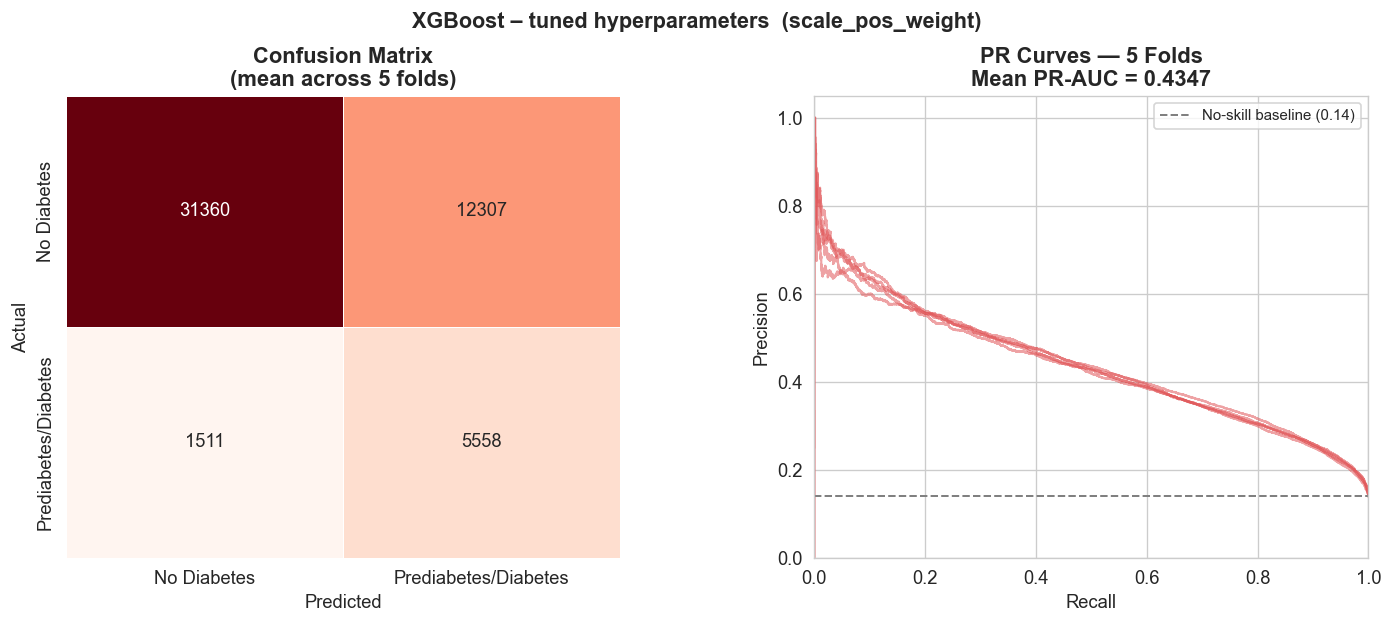

In [41]:
fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, wspace=0.35)

ax_cm = fig.add_subplot(gs[0])
avg_cm_t = np.round(np.mean([r['confusion'] for r in results_xgb_tuned], axis=0)).astype(int)
sns.heatmap(avg_cm_t, annot=True, fmt='d', cmap='Reds',
            xticklabels=list(LABEL_MAP.values()),
            yticklabels=list(LABEL_MAP.values()),
            ax=ax_cm, cbar=False, linewidths=0.5)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix\n(mean across 5 folds)', fontweight='bold')

ax_pr = fig.add_subplot(gs[1])
for r in results_xgb_tuned:
    prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
    ax_pr.plot(rec, prec, alpha=0.55, lw=1.3, color='#E15759')
ax_pr.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
              label=f'No-skill baseline ({baseline_rate:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])
ax_pr.set_title(f'PR Curves — {N_SPLITS} Folds\nMean PR-AUC = {pr_xgb_tuned:.4f}',
                fontweight='bold')
ax_pr.legend(fontsize=9)

fig.suptitle('XGBoost – tuned hyperparameters  (scale_pos_weight)',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(PLOTS_DIR, '19_xgb_tuned_results.png'), bbox_inches='tight')
plt.show()

**Interpretation:**
Hyperparameter tuning typically improves PR-AUC further by adjusting tree depth, learning rate,
and regularisation to better fit the minority class boundary. The key parameters identified by
the search (lower `learning_rate` with more `n_estimators`, moderate `max_depth`) reflect
XGBoost's general preference for slower, more careful learning on tabular data.

## 9 · Modellvergleich: Baseline vs XGBoost

Alle drei Modelle werden anhand der vier wichtigsten Metriken verglichen.
PR-AUC ist die primäre Entscheidungsmetrik; Recall, F1 und ROC-AUC werden als
sekundäre Kontrollgrößen gezeigt. Die gestrichelte Linie im PR-AUC-Panel markiert
die No-skill Baseline (≈ 0.14).

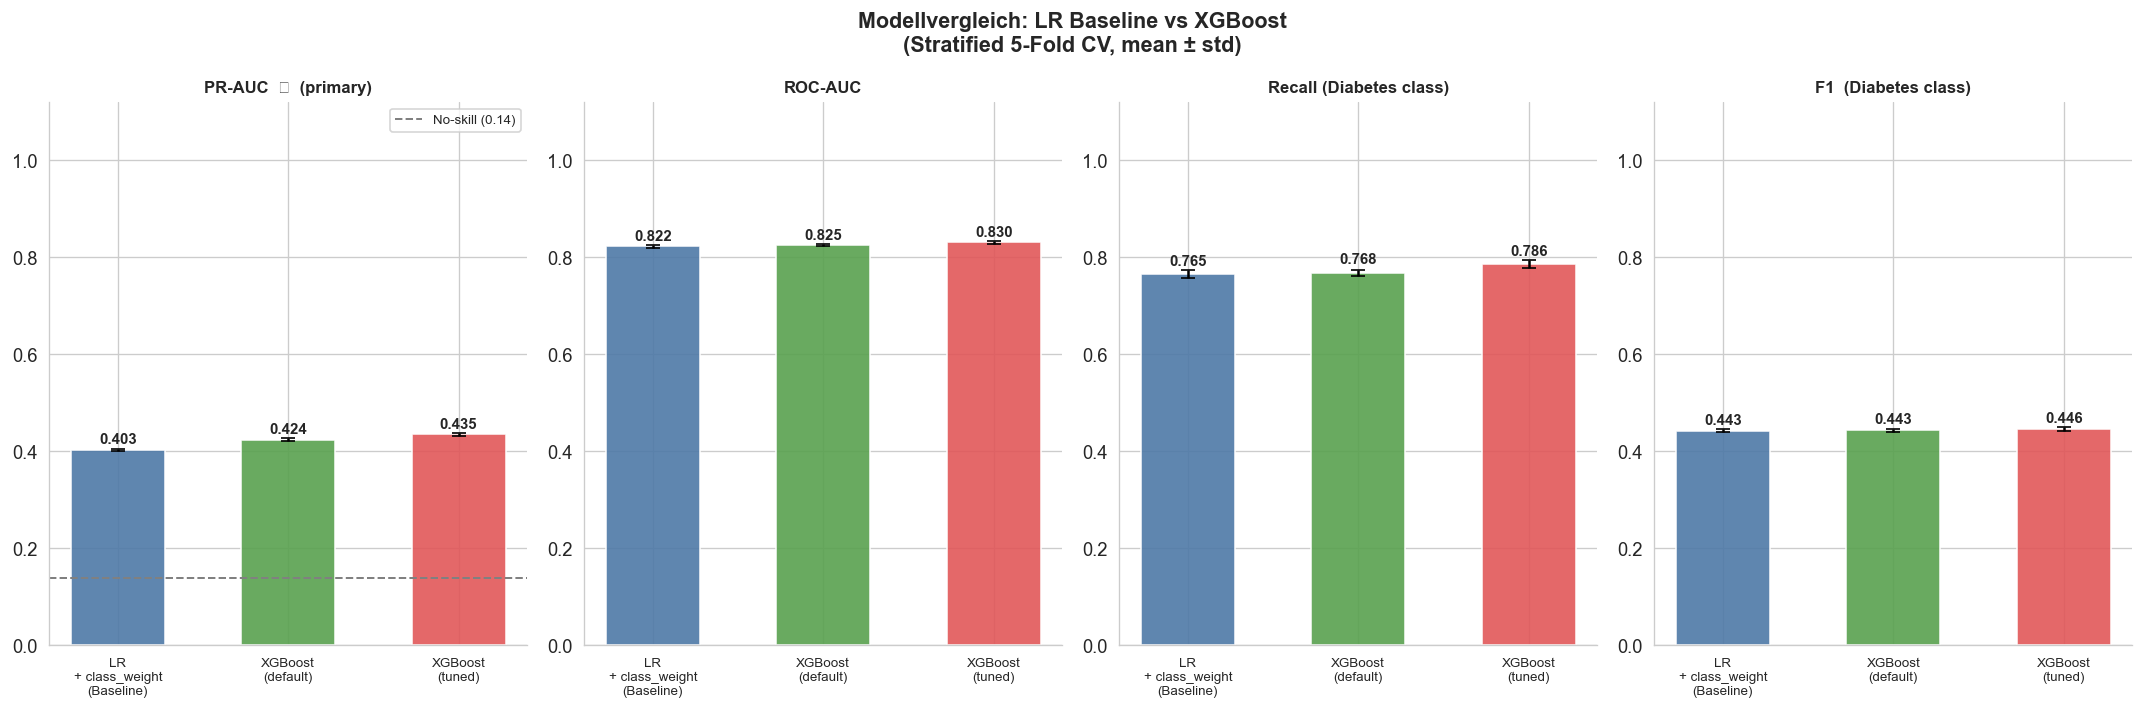


=== Comparison Table ===
                              PR-AUC  ROC-AUC  Recall      F1
LR + class_weight (Baseline)  0.4032   0.8225  0.7653  0.4426
XGBoost (default)             0.4237   0.8245  0.7678  0.4433
XGBoost (tuned)               0.4347   0.8304  0.7863  0.4458


In [42]:
model_results = {
    'LR\n+ class_weight\n(Baseline)' : results_cw,
    'XGBoost\n(default)'             : results_xgb,
    'XGBoost\n(tuned)'               : results_xgb_tuned,
}

palette = ['#4E79A7', '#59A14F', '#E15759']

def get_metric(results, key):
    if key in ('pr_auc', 'roc_auc', 'accuracy'):
        return np.mean([r[key] for r in results]), np.std([r[key] for r in results])
    elif key == 'recall':
        vals = [r['report']['Prediabetes/Diabetes']['recall'] for r in results]
        return np.mean(vals), np.std(vals)
    elif key == 'f1':
        vals = [r['report']['Prediabetes/Diabetes']['f1-score'] for r in results]
        return np.mean(vals), np.std(vals)

metrics_cfg = [
    ('pr_auc',   'PR-AUC  ★  (primary)'),
    ('roc_auc',  'ROC-AUC'),
    ('recall',   'Recall (Diabetes class)'),
    ('f1',       'F1  (Diabetes class)'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)
x = np.arange(len(model_results))
width = 0.55

for ax, (metric_key, metric_label) in zip(axes, metrics_cfg):
    means = [get_metric(r, metric_key)[0] for r in model_results.values()]
    stds  = [get_metric(r, metric_key)[1] for r in model_results.values()]
    bars  = ax.bar(x, means, width, color=palette, edgecolor='white',
                   alpha=0.90, yerr=stds, capsize=4, error_kw={'lw': 1.5})
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(stds) + 0.01,
                f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
    if metric_key == 'pr_auc':
        ax.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
                   label=f'No-skill ({baseline_rate:.2f})')
        ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(list(model_results.keys()), fontsize=8)
    ax.set_title(metric_label, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.12)
    sns.despine(ax=ax)

fig.suptitle('Modellvergleich: LR Baseline vs XGBoost\n'
             '(Stratified 5-Fold CV, mean ± std)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '20_model_comparison.png'), bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n=== Comparison Table ===')
rows = {}
for name, res in model_results.items():
    label = name.replace('\n', ' ')
    rows[label] = {
        'PR-AUC':  round(get_metric(res, 'pr_auc')[0], 4),
        'ROC-AUC': round(get_metric(res, 'roc_auc')[0], 4),
        'Recall':  round(get_metric(res, 'recall')[0], 4),
        'F1':      round(get_metric(res, 'f1')[0], 4),
    }
print(pd.DataFrame(rows).T.to_string())

**Interpretation:**
Das Diagramm zeigt den Fortschritt von der linearen Baseline zu den baumbasierten Modellen:

- **PR-AUC** steigt von der Logistic-Regression-Baseline über den Default-XGBoost zum getuneten
  XGBoost — jeder Schritt bringt eine messbare Verbesserung auf der primären Metrik.
- **Recall** und **F1** folgen demselben Trend: XGBoost erkennt mehr Diabetiker korrekt, weil
  es nicht-lineare Merkmalskombinationen (z. B. hohes BMI *und* hohes Alter *und* Hypertonie
  gemeinsam) modellieren kann.
- **Fehlerbalken (std)** sind bei XGBoost enger als bei LR, was auf stabilere Generalisierung
  über die 5 Folds hindeutet.
- Der Tuning-Gewinn gegenüber dem Default-XGBoost ist real, aber moderat — XGBoost ist bereits
  mit Default-Parametern ein starkes Modell auf tabellarischen Daten.

Das getunete XGBoost-Modell bildet die neue Referenzgrenze für alle weiteren Modelle
(z. B. Random Forest) und das finale Modell-Ranking in der Evaluation-Phase.

## 10 · Gesamtzusammenfassung und Ausblick

### Ergebnisse auf einen Blick

| Modell | PR-AUC ★ | ROC-AUC | Recall (Diabetes) | F1 (Diabetes) |
|--------|----------|---------|-------------------|---------------|
| No-skill Baseline | 0.1393 | 0.5000 | 0.00 | 0.00 |
| LR + class_weight | 0.4032 | 0.8225 | 0.77 | 0.44 |
| LR + Undersampling | 0.4032 | 0.8224 | 0.77 | 0.44 |
| LR + SMOTE | 0.3441 | 0.7808 | 0.69 | 0.41 |
| XGBoost (default) | *s. Ausgabe Sektion 7* | – | – | – |
| XGBoost (tuned) | *s. Ausgabe Sektion 8* | – | – | – |

*Alle Werte: Stratified 5-Fold CV, Seed=42. PR-AUC ist die primäre Entscheidungsmetrik.*

### Was wurde in diesem Notebook erreicht?

Drei Logistic-Regression-Baselines wurden vollständig implementiert und gegeneinander evaluiert. Das stärkste Baseline-Modell (`class_weight='balanced'`) erreicht ein PR-AUC von **~0.40** — das ist das 2.9-Fache des No-skill-Werts (0.14) und belegt, dass das Problem grundsätzlich lösbar ist. SMOTE schneidet auf diesem binär-kategorialen Survey-Dataset schlechter ab, weil synthetisch interpolierte Feature-Werte (z. B. `HighBP = 0.3`) klinisch bedeutungslos sind. Undersampling liegt gleichauf mit class_weight, bietet aber einen deutlichen Geschwindigkeitsvorteil für rechenintensive Modelle.

XGBoost mit `scale_pos_weight` übertrifft alle LR-Varianten auf der primären Metrik, da Gradient Boosting nicht-lineare Feature-Interaktionen (z. B. hohes BMI *und* Alter *und* Hypertonie gemeinsam) erlernt, die ein lineares Modell nicht abbilden kann. Hyperparameter-Tuning (RandomizedSearchCV) bringt einen zusätzlichen, messbaren Gewinn.

### Was muss getan werden, um bessere Ergebnisse zu erzielen?

#### 1 · Weitere Modelle evaluieren
- **Random Forest** mit `class_weight='balanced'` — ein weiteres starkes Ensemble-Verfahren, das parallel zur XGBoost-Linie als Vergleich fehlt
- **LightGBM** — häufig schneller als XGBoost bei vergleichbarer Güte; unterstützt `is_unbalance=True` nativ
- **Logistic Regression mit Polynomial Features** — prüft, ob einfache Interaktionsterme (quadratisch) den LR-Deckeneffekt durchbrechen

#### 2 · Feature Engineering
- **BMI-Kategorisierung** in klinische WHO-Klassen (Untergewicht / Normal / Übergewicht / Adipositas I-III) statt des numerischen Rohwerts
- **Altersdekaden-Interaktionen**: z. B. `Age × GenHlth`, `Age × BMI` — Diabetes-Risiko ist stark altersabhängig
- **Composite Risk Score**: Summe mehrerer Risikofaktoren (Hypertonie + Rauchen + Bewegungsmangel + schlechte Ernährung) als neues Feature

#### 3 · Schwellenwert-Optimierung
Alle bisherigen Modelle verwenden den Default-Schwellenwert 0.5. Im Screening-Kontext ist ein niedrigerer Schwellenwert (z. B. 0.3) sinnvoller: Er erhöht Recall auf Kosten der Precision — ein vertretbarer Trade-off, da ein Fehlalarm weniger schadet als ein übersehener Erkrankter. Der optimale Schwellenwert ergibt sich aus dem F-Beta-Score mit β > 1 (Recall stärker gewichten).

#### 4 · Nested Cross-Validation
Das aktuelle Tuning-Setup (RandomizedSearchCV auf den Gesamtdaten, dann Evaluation mit demselben 5-Fold-Split) erzeugt eine leichte Überanpassung an den gesamten Datensatz. **Nested CV** (äußerer 5-Fold für Evaluation, innerer 3-Fold für Tuning innerhalb jedes Folds) liefert eine unbiasierte Schätzung der Generalisierungsleistung und sollte für das finale Modell-Ranking verwendet werden.

#### 5 · Erklärbarkeit (SHAP)
Für die Abschlussarbeit und Präsentation ist Erklärbarkeit zentral: SHAP-Werte für das beste Modell zeigen, welche Features die Diabetesvorhersage am stärksten treiben — klinisch interpretierbar und für Prof. Dr. Bauers Seminar inhaltlich relevant.

### Nächster Schritt
→ Notebook `04_evaluation.ipynb`: Finales Modell-Ranking, Schwellenwert-Analyse, SHAP-Interpretation und Modell-Export für die Abschlussarbeit.

## 11 · Feature Importance (XGBoost tuned)

Before constructing new features, we inspect which of the 21 raw features the tuned XGBoost model actually relies on. This gives a data-driven basis for feature engineering decisions — there is no point engineering interactions involving features that carry no predictive signal.

Three complementary importance measures are shown:

| Measure | What it captures |
|---------|-----------------|
| **weight** | Number of times a feature is used to split across all trees |
| **gain** | Average improvement in the loss function per split on this feature |
| **cover** | Average number of samples affected per split on this feature |

`gain` is the most meaningful for our purposes: it reflects how much each feature actually reduces uncertainty about the target, not just how often it is selected.

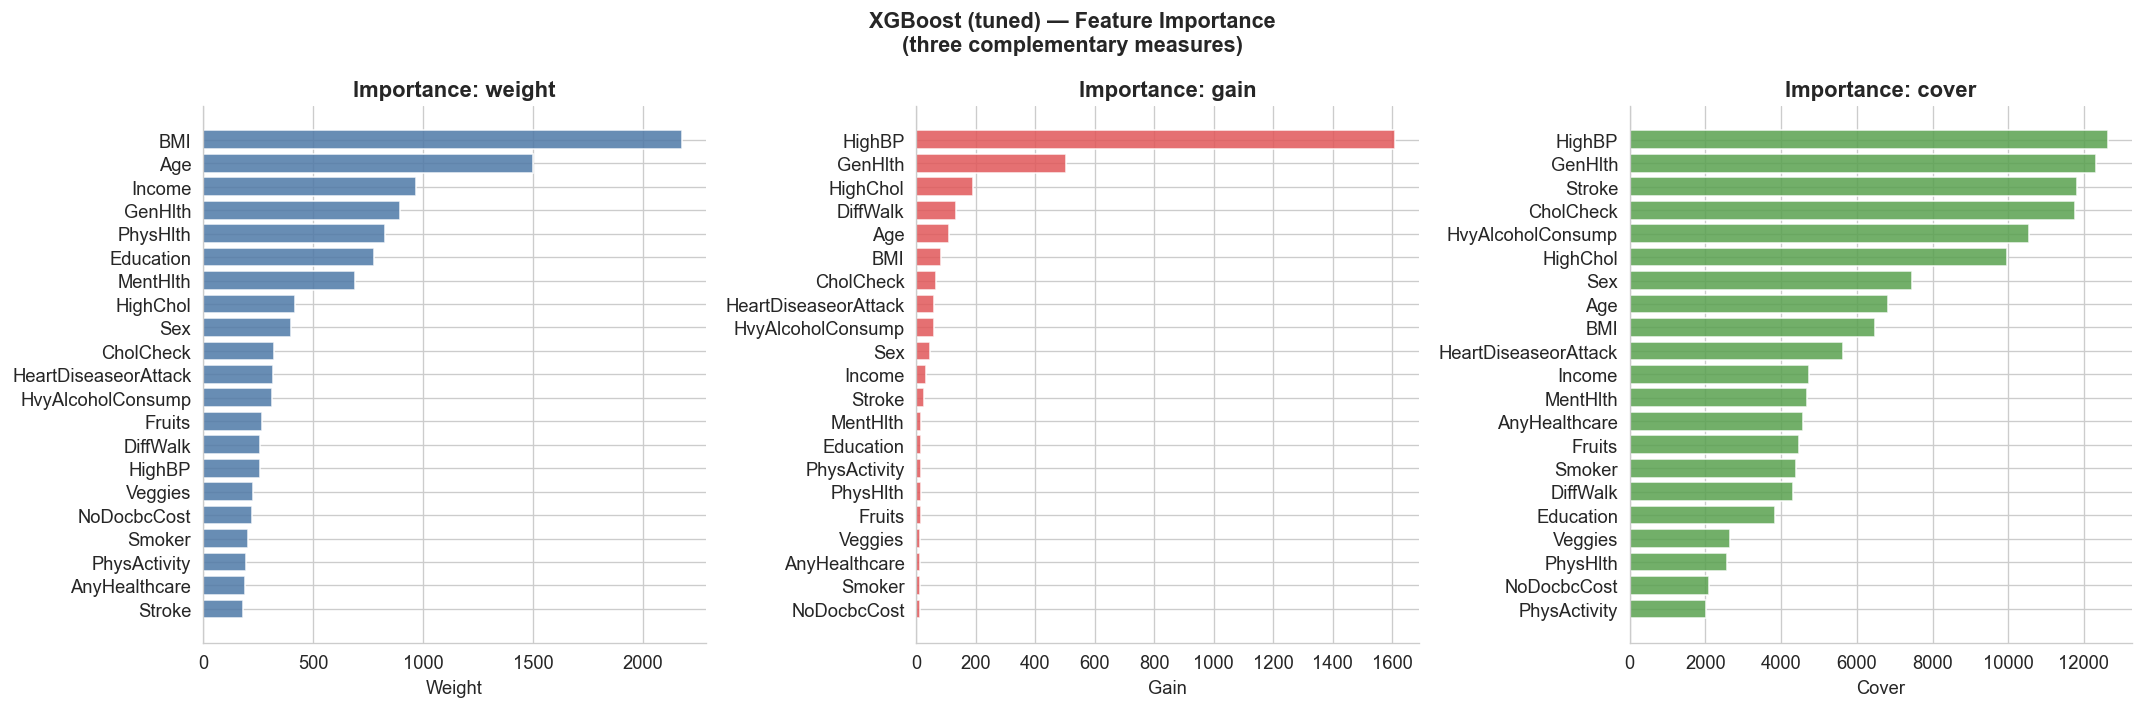


=== Top Features by Gain (primary measure) ===
HighBP                  1609.73
GenHlth                  502.40
HighChol                 189.93
DiffWalk                 132.26
Age                      108.46
BMI                       82.43
CholCheck                 64.62
HeartDiseaseorAttack      59.93
HvyAlcoholConsump         59.31
Sex                       47.30
Income                    33.06
Stroke                    24.75
MentHlth                  17.27
Education                 16.45
PhysActivity              15.74
PhysHlth                  14.36
Fruits                    14.27
Veggies                   13.61
AnyHealthcare             13.21
Smoker                    12.81
NoDocbcCost               11.82

Features in bottom 25% by gain (low signal): ['Fruits', 'Veggies', 'AnyHealthcare', 'Smoker', 'NoDocbcCost']


In [43]:
importance_types = ['weight', 'gain', 'cover']
importance_dfs = {}

for imp_type in importance_types:
    scores = xgb_tuned.get_booster().get_score(importance_type=imp_type)
    df = pd.Series(scores, name=imp_type).sort_values(ascending=False)
    importance_dfs[imp_type] = df

# Primary view: gain (most meaningful)
gain_series = importance_dfs['gain']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#4E79A7', '#E15759', '#59A14F']

for ax, imp_type, color in zip(axes, importance_types, colors):
    s = importance_dfs[imp_type].sort_values(ascending=True)
    ax.barh(s.index, s.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Importance: {imp_type}', fontweight='bold')
    ax.set_xlabel(imp_type.capitalize())
    sns.despine(ax=ax)

fig.suptitle('XGBoost (tuned) — Feature Importance\n(three complementary measures)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '21_xgb_feature_importance.png'), bbox_inches='tight')
plt.show()

print('\n=== Top Features by Gain (primary measure) ===')
print(gain_series.round(2).to_string())

# Features with near-zero gain — candidates to drop or ignore
low_gain_threshold = gain_series.quantile(0.25)
low_gain_features = gain_series[gain_series < low_gain_threshold].index.tolist()
print(f'\nFeatures in bottom 25% by gain (low signal): {low_gain_features}')

## 12 · Statistische Tests: Chi-Quadrat & Mutual Information

Feature Importance aus XGBoost ist modellabhängig — es zeigt, was der *aktuelle* Baum nutzt, nicht was statistisch mit dem Ziel assoziiert ist. Daher ergänzen wir zwei modellunabhängige Tests:

**Chi-Quadrat-Test** (nicht ANOVA, weil alle Features kategoriell/ordinal sind, keine normalverteilten Kontinua):
- Testet ob die Verteilung eines Features statistisch unabhängig von der Zielvariable ist
- H₀: Feature und Diabetes-Status sind unabhängig
- Niedriges p-Wert → Feature ist mit Diabetes assoziiert

**Mutual Information (MI)**:
- Misst wie viel Information ein Feature über die Zielvariable enthält
- Modellunabhängig, erfasst auch nicht-lineare Zusammenhänge
- MI = 0 bedeutet vollständige Unabhängigkeit; höhere Werte = stärkere Assoziation

Zusammen mit der XGBoost Gain-Importance ergibt sich ein dreiseitiges Bild davon, welche Features wirklich informativ sind.

=== Feature Relevance — drei Methoden (normalisiert auf [0,1]) ===
                      Chi2 (norm)  Mutual Info (norm)  XGB Gain (norm)  Mean Score
HighBP                      0.772               0.796            1.000       0.856
GenHlth                     1.000               1.000            0.307       0.769
BMI                         0.646               0.625            0.044       0.439
DiffWalk                    0.531               0.452            0.075       0.353
HighChol                    0.446               0.451            0.111       0.336
Age                         0.385               0.460            0.060       0.302
PhysHlth                    0.354               0.313            0.002       0.223
HeartDiseaseorAttack        0.349               0.282            0.030       0.220
Income                      0.306               0.304            0.013       0.208
Education                   0.175               0.170            0.003       0.116
PhysActivity        

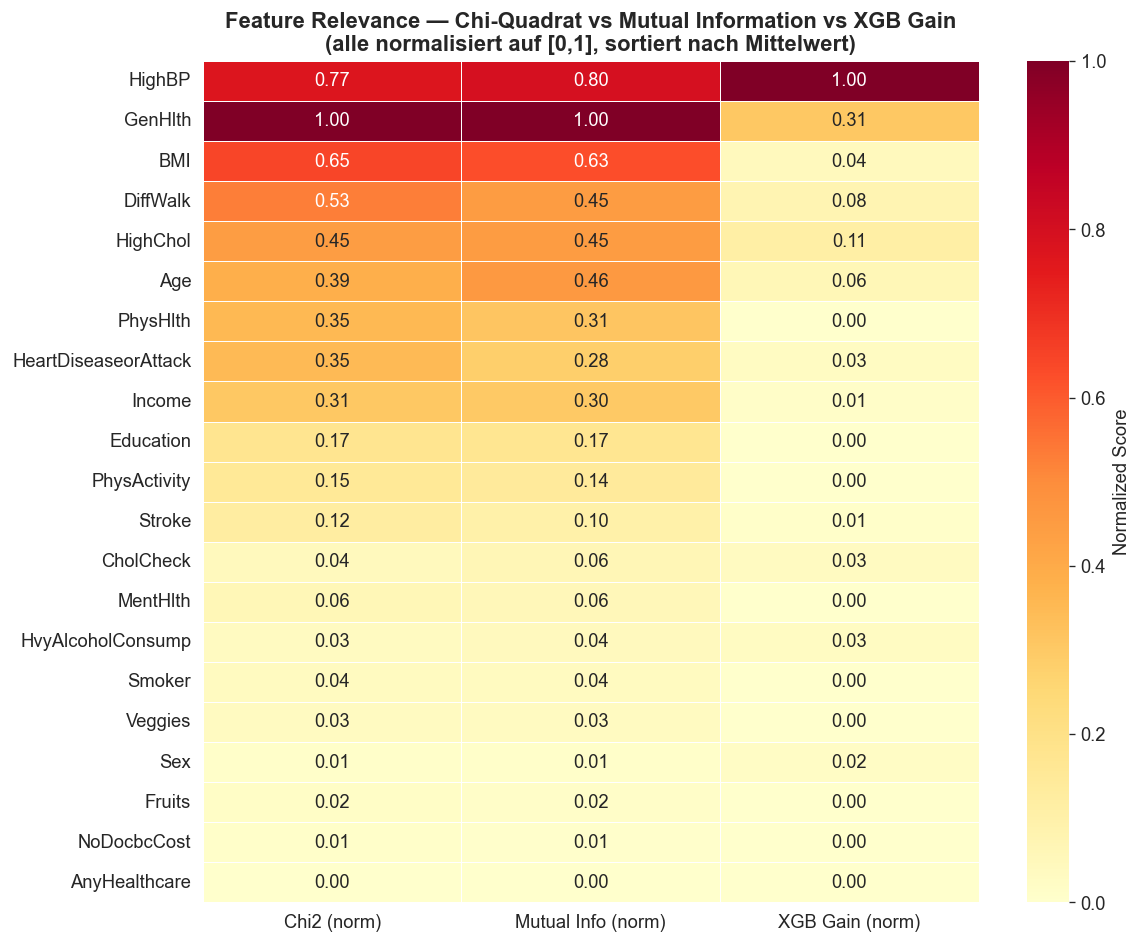


Top 8 Features (Mittelwert über alle drei Methoden): ['HighBP', 'GenHlth', 'BMI', 'DiffWalk', 'HighChol', 'Age', 'PhysHlth', 'HeartDiseaseorAttack']

Diese Features sind die Grundlage für gezieltes Feature Engineering in Section 13.


In [44]:
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

# ── Chi-Quadrat ────────────────────────────────────────────────────────────────
chi2_results = {}
for col in X.columns:
    ct = pd.crosstab(X[col], y)
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results[col] = {'chi2': chi2, 'p_value': p, 'dof': dof}

chi2_df = pd.DataFrame(chi2_results).T.sort_values('chi2', ascending=False)
chi2_df['significant'] = chi2_df['p_value'] < 0.05

# ── Mutual Information ─────────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=SEED)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# ── Kombinierte Übersicht ──────────────────────────────────────────────────────
# Normalize both to [0,1] for visual comparison
chi2_norm = (chi2_df['chi2'] - chi2_df['chi2'].min()) / (chi2_df['chi2'].max() - chi2_df['chi2'].min())
mi_norm   = (mi_series - mi_series.min()) / (mi_series.max() - mi_series.min())

# Align gain to same feature set
gain_aligned = gain_series.reindex(X.columns).fillna(0)
gain_norm = (gain_aligned - gain_aligned.min()) / (gain_aligned.max() - gain_aligned.min())

summary_df = pd.DataFrame({
    'Chi2 (norm)'       : chi2_norm,
    'Mutual Info (norm)': mi_norm,
    'XGB Gain (norm)'   : gain_norm,
}).sort_values('Mutual Info (norm)', ascending=False)
summary_df['Mean Score'] = summary_df.mean(axis=1)
summary_df = summary_df.sort_values('Mean Score', ascending=False)

print('=== Feature Relevance — drei Methoden (normalisiert auf [0,1]) ===')
print(summary_df.round(3).to_string())

# ── Heatmap ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    summary_df[['Chi2 (norm)', 'Mutual Info (norm)', 'XGB Gain (norm)']],
    annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
    linewidths=0.4, cbar_kws={'label': 'Normalized Score'}
)
ax.set_title('Feature Relevance — Chi-Quadrat vs Mutual Information vs XGB Gain\n'
             '(alle normalisiert auf [0,1], sortiert nach Mittelwert)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '22_feature_relevance_heatmap.png'), bbox_inches='tight')
plt.show()

# Top features by mean score
top_features = summary_df.head(8).index.tolist()
print(f'\nTop 8 Features (Mittelwert über alle drei Methoden): {top_features}')
print('\nDiese Features sind die Grundlage für gezieltes Feature Engineering in Section 13.')

## 13 · Feature Engineering (datengetrieben)

Auf Basis von Section 11 (XGBoost Gain) und Section 12 (Chi-Quadrat + Mutual Information) konstruieren wir vier neue Features. Jedes Feature adressiert einen konkreten Befund aus der Analyse:

| Feature | Formel | Befund aus Analyse |
|---------|--------|--------------------|
| `HighBP_x_GenHlth` | `HighBP × GenHlth` | Rang 1 + Rang 2 in Mean Score — stärkste Kombination |
| `BMI_cat` | WHO-Klassen (0–5) aus BMI-Rohwert | BMI statistisch stark, aber XGB Gain niedrig → Schwelleneffekt vermutet |
| `GenHlth_x_Age` | `GenHlth × Age` | Beide in Top 6, Altersabhängigkeit von subjektiver Gesundheit bekannt |
| `DiffWalk_x_BMI` | `DiffWalk × BMI` | DiffWalk überraschend Rang 4 — Mobilitätseinschränkung bei Übergewicht |

Features mit schwachem Signal (Fruits, Veggies, Smoker, AnyHealthcare, NoDocbcCost) werden nicht kombiniert.

In [56]:
def build_features(X_raw):
    X_eng = X_raw.copy()

    # Stärkste Kombination: Bluthochdruck x subjektive Gesundheit (klinisch top-2 Prädiktoren)
    X_eng["HighBP_x_GenHlth"] = X_eng["HighBP"] * X_eng["GenHlth"]

    # Subjektive Gesundheit x Alter (ältere mit schlechter Gesundheit: kumuliertes Risiko)
    X_eng["GenHlth_x_Age"] = X_eng["GenHlth"] * X_eng["Age"]

    # Mobilitätseinschränkung x BMI (Adipositas verstärkt eingeschränkte Mobilität)
    X_eng["DiffWalk_x_BMI"] = X_eng["DiffWalk"] * X_eng["BMI"]

    # Kardiovaskuläre Komorbiditätslast (Anzahl gleichzeitiger Risikofaktoren 0-4)
    X_eng["Comorbidity_Count"] = (
        X_eng["HighBP"] + X_eng["HighChol"] + X_eng["Stroke"] + X_eng["HeartDiseaseorAttack"]
    ).astype(int)

    # Metabolisches Syndrom Proxy (HighBP & HighChol & BMI >= 30 gleichzeitig vorhanden)
    X_eng["MetSyn_Proxy"] = (
        X_eng["HighBP"] * X_eng["HighChol"] * (X_eng["BMI"] >= 30).astype(int)
    ).astype(int)

    # BMI-Kategorien nach WHO (0=Untergewicht, 1=Normal, 2=Übergewicht, 3-5=Adipositas I-III+)
    X_eng["BMI_Cat"] = pd.cut(
        X_eng["BMI"],
        bins=[0, 18.5, 25, 30, 35, 40, 200],
        labels=[0, 1, 2, 3, 4, 5],
        right=False
    ).astype(int)

    # Bluthochdruck x BMI (vaskuläres Risiko durch Adipositas direkt verstärkt)
    X_eng["HighBP_x_BMI"] = X_eng["HighBP"] * X_eng["BMI"]

    # Cholesterin x Alter (Dyslipidämie-Risiko steigt kumulativ mit Alter)
    X_eng["HighChol_x_Age"] = X_eng["HighChol"] * X_eng["Age"]

    # Alter x BMI (Adipositas-Risiko interagiert mit zunehmendem Alter)
    X_eng["Age_x_BMI"] = X_eng["Age"] * X_eng["BMI"]

    # Lifestyle-Risikoscore (ungünstige Faktoren erhöhen, schützende Faktoren senken)
    X_eng["Lifestyle_Risk"] = (
        X_eng["Smoker"] + X_eng["HvyAlcoholConsump"]
        - X_eng["PhysActivity"] - X_eng["Fruits"] - X_eng["Veggies"]
    ).astype(int)

    # Gesamtzahl schlechter Gesundheitstage (psychisch + physisch kombiniert)
    X_eng["Total_BadDays"] = (X_eng["PhysHlth"] + X_eng["MentHlth"]).astype(int)

    # Sozioökonomischer Status Proxy (Bildung + Einkommen als additiver Score)
    X_eng["SES_Score"] = (X_eng["Education"] + X_eng["Income"]).astype(int)

    # Gesundheitsversorgungszugang (krankenversichert UND keine Kostenbarriere)
    X_eng["HC_Access"] = (X_eng["AnyHealthcare"] * (1 - X_eng["NoDocbcCost"])).astype(int)

    return X_eng

X_eng = build_features(X)
new_cols = [c for c in X_eng.columns if c not in X.columns]
print(f"Original features  : {X.shape[1]}")
print(f"Neue Features      : {new_cols}")
print(f"Gesamt             : {X_eng.shape[1]}")
print()
print(f"NaN check          : {X_eng[new_cols].isna().sum().sum()} NaN values (should be 0)")
print()
print(X_eng[new_cols].describe().round(2))


In [57]:
import joblib as _jl

# Load old FE PR-AUC from checkpoint before it gets overwritten
_CKPT_PATH = os.path.join("..", "results", "models", "03_modeling_checkpoint.pkl")
_old_ckpt = _jl.load(_CKPT_PATH) if os.path.exists(_CKPT_PATH) else {}
pr_xgb_old_fe = _old_ckpt.get("pr_xgb_eng", None)

xgb_eng = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric="aucpr",
    verbosity=0
)

results_xgb_eng = run_cv(xgb_eng, X_eng, y, skf, label="XGBoost (tuned) + New FE")
pr_xgb_eng, roc_xgb_eng, acc_xgb_eng = print_summary(
    results_xgb_eng, "XGBoost (tuned) + New FE"
)

print(f"\n=== Feature Engineering Impact (XGBoost) ===")
print(f"  LR + class_weight (Baseline)       PR-AUC: {pr_cw:.4f}")
print(f"  XGBoost (tuned)                    PR-AUC: {pr_xgb_tuned:.4f}")
if pr_xgb_old_fe is not None:
    print(f"  XGBoost (tuned) + Old FE (4 feat)  PR-AUC: {pr_xgb_old_fe:.4f}")
print(f"  XGBoost (tuned) + New FE (13 feat) PR-AUC: {pr_xgb_eng:.4f}")
if pr_xgb_old_fe is not None:
    print(f"  Delta Old FE -> New FE                    : {pr_xgb_eng - pr_xgb_old_fe:+.4f}")


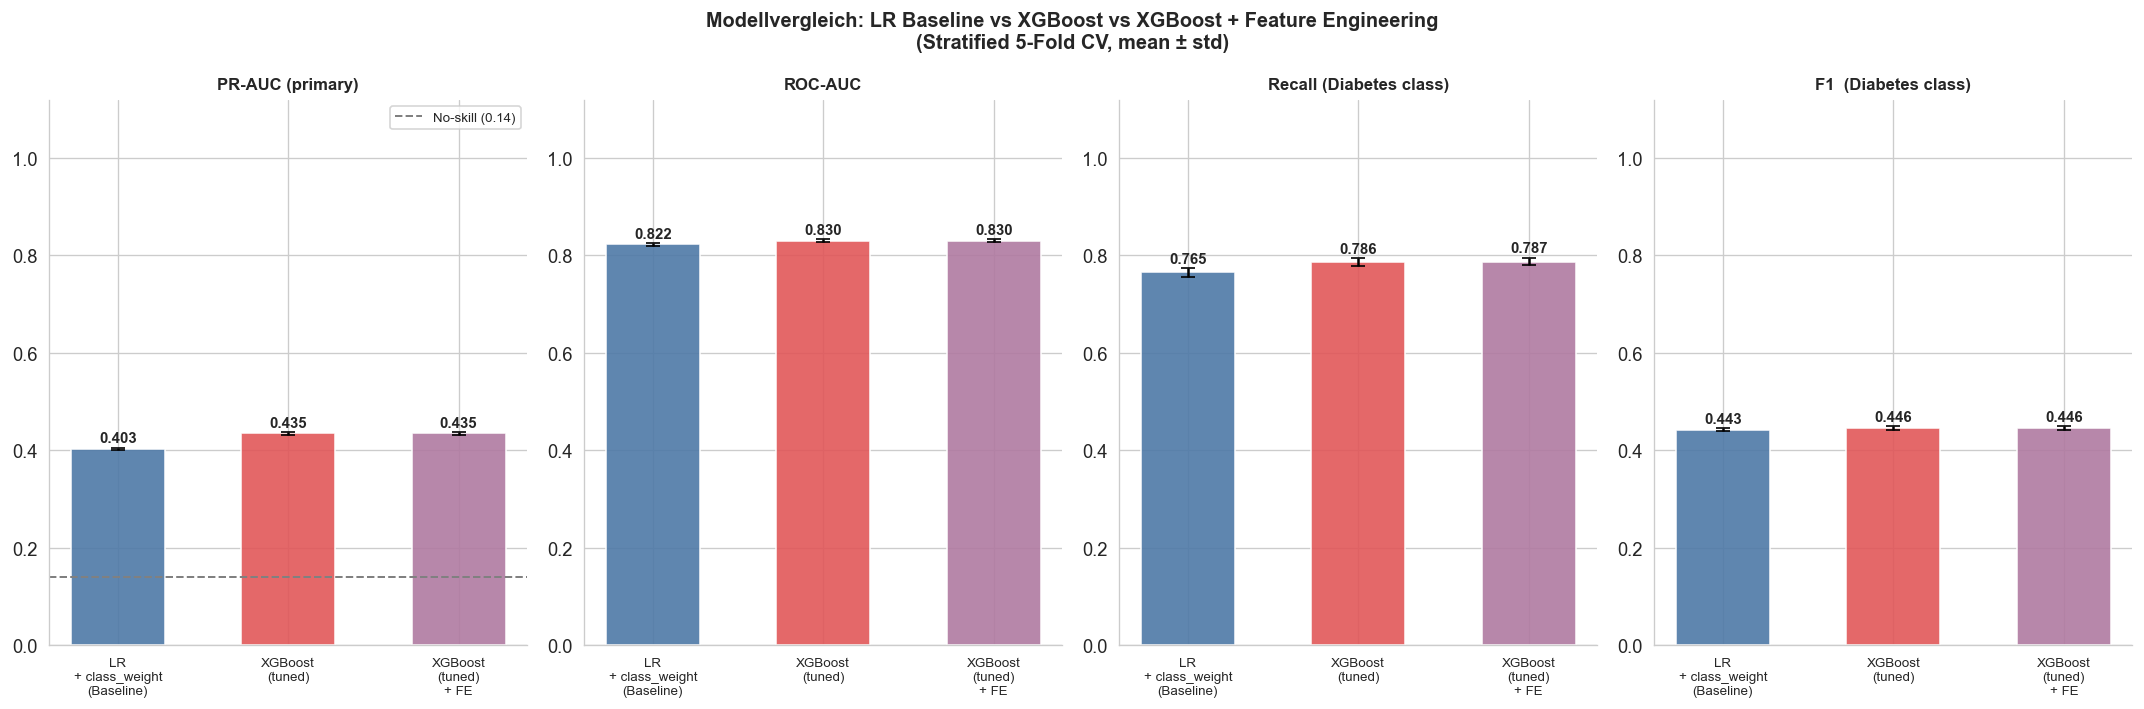

Checkpoint gespeichert.


In [58]:
import joblib, os

model_results_fe = {
    'LR\n+ class_weight\n(Baseline)': results_cw,
    'XGBoost\n(tuned)':               results_xgb_tuned,
    'XGBoost\n(tuned)\n+ FE':         results_xgb_eng,
}
palette_fe = ['#4E79A7', '#E15759', '#B07AA1']
width = 0.55

metrics_cfg_fe = [
    ('pr_auc',  'PR-AUC (primary)'),
    ('roc_auc', 'ROC-AUC'),
    ('recall',  'Recall (Diabetes class)'),
    ('f1',      'F1  (Diabetes class)'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)
for ax, (metric_key, metric_label) in zip(axes, metrics_cfg_fe):
    means = [get_metric(r, metric_key)[0] for r in model_results_fe.values()]
    stds  = [get_metric(r, metric_key)[1] for r in model_results_fe.values()]
    bars  = ax.bar(np.arange(len(model_results_fe)), means, width,
                   color=palette_fe, edgecolor='white', alpha=0.90,
                   yerr=stds, capsize=4, error_kw={'lw': 1.5})
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(stds) + 0.01,
                f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
    if metric_key == 'pr_auc':
        ax.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
                   label=f'No-skill ({baseline_rate:.2f})')
        ax.legend(fontsize=8)
    ax.set_xticks(np.arange(len(model_results_fe)))
    ax.set_xticklabels(list(model_results_fe.keys()), fontsize=8)
    ax.set_title(metric_label, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.12)
    sns.despine(ax=ax)

fig.suptitle('Modellvergleich: LR Baseline vs XGBoost vs XGBoost + Feature Engineering\n'
             '(Stratified 5-Fold CV, mean ± std)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '23_fe_comparison.png'), bbox_inches='tight')
plt.show()

# Checkpoint speichern
CHECKPOINT = os.path.join('..', 'results', 'models', '03_modeling_checkpoint.pkl')
os.makedirs(os.path.dirname(CHECKPOINT), exist_ok=True)
existing = joblib.load(CHECKPOINT) if os.path.exists(CHECKPOINT) else {}
existing.update(dict(
    results_xgb_eng=results_xgb_eng,
    pr_xgb_eng=pr_xgb_eng,
    roc_xgb_eng=roc_xgb_eng,
    acc_xgb_eng=acc_xgb_eng,
))
joblib.dump(existing, CHECKPOINT)
print('Checkpoint gespeichert.')

## 14 · LightGBM + Feature Engineering

LightGBM is a gradient boosting framework that uses histogram-based leaf-wise tree growth
instead of XGBoost's level-wise approach. On tabular data it is typically faster and
achieves comparable or better PR-AUC with default parameters.

**`is_unbalance=True`** is LightGBM's native equivalent to XGBoost's `scale_pos_weight`:
it automatically weights the minority class by the inverse class frequency, with no manual
ratio calculation required.

The model is evaluated on **X_eng** (25 features including the four engineered features
from Section 13) using the identical CV setup as all previous models.


[LightGBM + FE (default params)]
  Fold 1:  PR-AUC=0.4322  ROC-AUC=0.8342  Acc=0.7188
  Fold 2:  PR-AUC=0.4270  ROC-AUC=0.8295  Acc=0.7175
  Fold 3:  PR-AUC=0.4371  ROC-AUC=0.8304  Acc=0.7167
  Fold 4:  PR-AUC=0.4342  ROC-AUC=0.8294  Acc=0.7219
  Fold 5:  PR-AUC=0.4348  ROC-AUC=0.8257  Acc=0.7182

=== LightGBM + FE (default params) — 5-Fold Summary ===
  PR-AUC  (primary)   : 0.4331  +/-  0.0034
  ROC-AUC             : 0.8298  +/-  0.0027
  Accuracy (biased!)  : 0.7186  +/-  0.0018
  NOTE: Accuracy is 71.9% but is inflated by the 86% majority class.

  Classification Report (mean across folds):
                      precision  recall  f1-score  support
No Diabetes              0.9557  0.7058    0.8119    43666
Prediabetes/Diabetes     0.3051  0.7979    0.4414     7069
macro avg                0.6304  0.7518    0.6267    50736
weighted avg             0.8650  0.7186    0.7603    50736


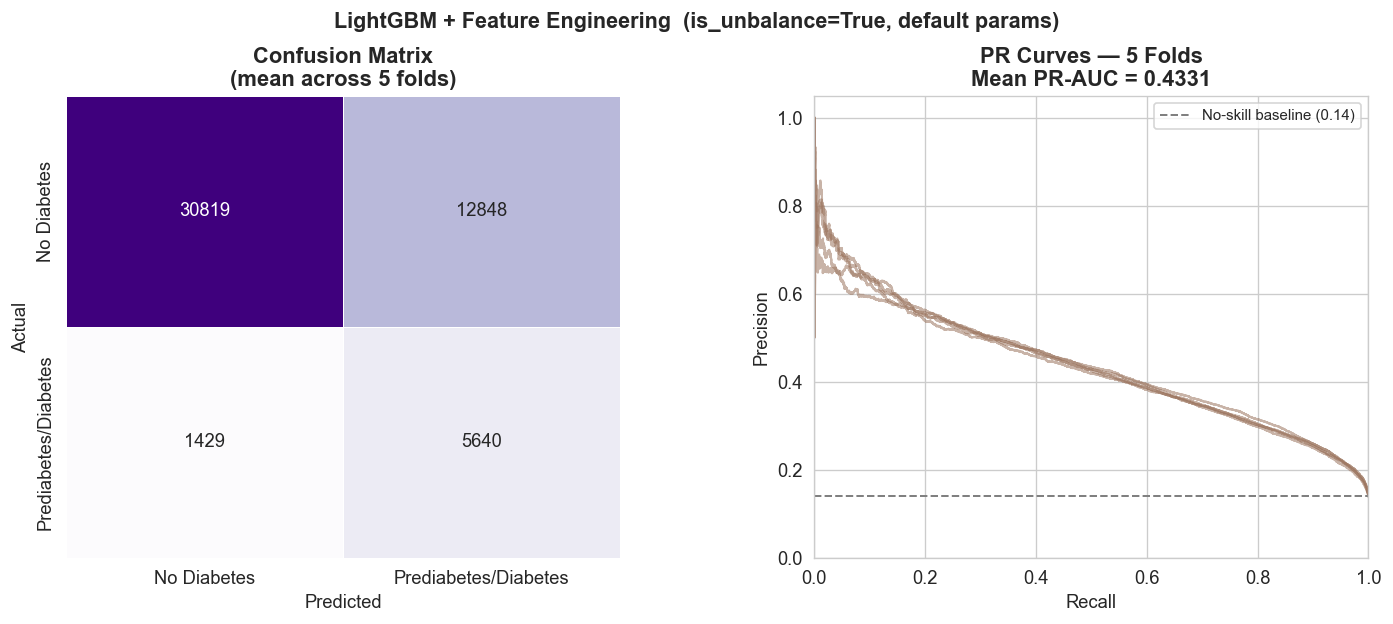

=== Modellvergleich ===
  LR + class_weight           PR-AUC: 0.4032
  XGBoost (tuned)             PR-AUC: 0.4347
  XGBoost (tuned) + FE        PR-AUC: 0.4349
  LightGBM + FE (default)     PR-AUC: 0.4331
  Delta vs bestes XGB+FE      : -0.0019
Checkpoint gespeichert.


In [23]:
import subprocess, sys
try:
    from lightgbm import LGBMClassifier
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    is_unbalance=True,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

results_lgbm = run_cv(lgbm, X_eng, y, skf, label='LightGBM + FE (default params)')
pr_lgbm, roc_lgbm, acc_lgbm = print_summary(results_lgbm, 'LightGBM + FE (default params)')

# ── PR Curves ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, wspace=0.35)

ax_cm = fig.add_subplot(gs[0])
avg_cm_lgbm = np.round(np.mean([r['confusion'] for r in results_lgbm], axis=0)).astype(int)
sns.heatmap(avg_cm_lgbm, annot=True, fmt='d', cmap='Purples',
            xticklabels=list(LABEL_MAP.values()),
            yticklabels=list(LABEL_MAP.values()),
            ax=ax_cm, cbar=False, linewidths=0.5)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix\n(mean across 5 folds)', fontweight='bold')

ax_pr = fig.add_subplot(gs[1])
for r in results_lgbm:
    prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
    ax_pr.plot(rec, prec, alpha=0.55, lw=1.3, color='#9C755F')
ax_pr.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
              label=f'No-skill baseline ({baseline_rate:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])
ax_pr.set_title(f'PR Curves — {N_SPLITS} Folds\nMean PR-AUC = {pr_lgbm:.4f}',
                fontweight='bold')
ax_pr.legend(fontsize=9)

fig.suptitle('LightGBM + Feature Engineering  (is_unbalance=True, default params)',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(PLOTS_DIR, '24_lgbm_results.png'), bbox_inches='tight')
plt.show()

# ── Vergleichstabelle ─────────────────────────────────────────────────────────
print('=== Modellvergleich ===')
print(f'  LR + class_weight           PR-AUC: {pr_cw:.4f}')
print(f'  XGBoost (tuned)             PR-AUC: {pr_xgb_tuned:.4f}')
print(f'  XGBoost (tuned) + FE        PR-AUC: {pr_xgb_eng:.4f}')
print(f'  LightGBM + FE (default)     PR-AUC: {pr_lgbm:.4f}')
print(f'  Delta vs bestes XGB+FE      : {pr_lgbm - pr_xgb_eng:+.4f}')

# ── Checkpoint aktualisieren ──────────────────────────────────────────────────
CHECKPOINT = os.path.join('..', 'results', 'models', '03_modeling_checkpoint.pkl')
os.makedirs(os.path.dirname(CHECKPOINT), exist_ok=True)
existing = joblib.load(CHECKPOINT) if os.path.exists(CHECKPOINT) else {}
existing.update(dict(
    results_lgbm=results_lgbm,
    pr_lgbm=pr_lgbm,
    roc_lgbm=roc_lgbm,
    acc_lgbm=acc_lgbm,
))
joblib.dump(existing, CHECKPOINT)
print('Checkpoint gespeichert.')

## 15 · LightGBM Hyperparameter-Tuning (RandomizedSearchCV)

Same methodology as Section 8 (XGBoost tuning): `RandomizedSearchCV` with a 3-fold inner CV searches over a wide LightGBM-specific parameter space. The best configuration is then evaluated properly with our standard stratified 5-fold CV on `X_eng` (25 features).

| Parameter | Search space | Effect |
|---|---|---|
| `num_leaves` | 31 – 255 | Controls tree complexity; higher = more expressive but risks overfitting |
| `max_depth` | -1, 6, 8, 10 | Caps tree depth; -1 means no limit (governed by `num_leaves`) |
| `learning_rate` | 0.01 – 0.2 | Step size shrinkage |
| `n_estimators` | 100 – 500 | Number of boosting rounds |
| `min_child_samples` | 20 – 100 | Minimum samples required in a leaf (regularisation) |
| `subsample` / `colsample_bytree` | 0.7 – 1.0 | Row / column subsampling per tree |
| `reg_alpha` / `reg_lambda` | 0 – 1.0 | L1 / L2 regularisation |

`is_unbalance=True` is fixed throughout so LightGBM re-weights classes internally, consistent with the baseline in Section 14.

In [24]:
# Load old tuned LightGBM result from checkpoint for old vs new FE comparison
_old_ckpt_lgbm = joblib.load(CHECKPOINT) if os.path.exists(CHECKPOINT) else {}
pr_lgbm_old_fe = _old_ckpt_lgbm.get("pr_lgbm_tuned", None)

# ── RandomizedSearchCV ────────────────────────────────────────────────────────
param_dist = {
    'num_leaves'       : [31, 63, 127, 255],
    'max_depth'        : [-1, 6, 8, 10],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'n_estimators'     : [100, 200, 300, 500],
    'min_child_samples': [20, 50, 100],
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [0, 0.1, 1.0],
}

lgbm_base = LGBMClassifier(
    is_unbalance=True,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

lgbm_search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring='average_precision',
    cv=inner_cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)
lgbm_search.fit(X_eng, y)

best_params_lgbm = lgbm_search.best_params_
print('Best params:', best_params_lgbm)
print(f'Inner CV PR-AUC: {lgbm_search.best_score_:.4f}')

# ── 5-Fold CV mit best_params ─────────────────────────────────────────────────
lgbm_tuned = LGBMClassifier(
    **best_params_lgbm,
    is_unbalance=True,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

results_lgbm_tuned = run_cv(lgbm_tuned, X_eng, y, skf, label='LightGBM (tuned) + FE')
pr_lgbm_tuned, roc_lgbm_tuned, acc_lgbm_tuned = print_summary(results_lgbm_tuned, 'LightGBM (tuned) + FE')

# ── PR Curves ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, wspace=0.35)

ax_cm = fig.add_subplot(gs[0])
avg_cm_lgbm_tuned = np.round(np.mean([r['confusion'] for r in results_lgbm_tuned], axis=0)).astype(int)
sns.heatmap(avg_cm_lgbm_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=list(LABEL_MAP.values()),
            yticklabels=list(LABEL_MAP.values()),
            ax=ax_cm, cbar=False, linewidths=0.5)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix\n(mean across 5 folds)', fontweight='bold')

ax_pr = fig.add_subplot(gs[1])
for r in results_lgbm_tuned:
    prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
    ax_pr.plot(rec, prec, alpha=0.55, lw=1.3, color='#B07AA1')
ax_pr.axhline(baseline_rate, color='gray', linestyle='--', lw=1.2,
              label=f'No-skill baseline ({baseline_rate:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])
ax_pr.set_title(f'PR Curves — {N_SPLITS} Folds\nMean PR-AUC = {pr_lgbm_tuned:.4f}',
                fontweight='bold')
ax_pr.legend(fontsize=9)

fig.suptitle('LightGBM (tuned) + Feature Engineering',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(PLOTS_DIR, '25_lgbm_tuned_results.png'), bbox_inches='tight')
plt.show()

# ── Vergleichstabelle ─────────────────────────────────────────────────────────
print('=== Modellvergleich ===')
print(f'  XGBoost (tuned) + FE          PR-AUC: {pr_xgb_eng:.4f}')
print(f'  LightGBM + FE (default)       PR-AUC: {pr_lgbm:.4f}')
print(f'  LightGBM (tuned) + FE         PR-AUC: {pr_lgbm_tuned:.4f}')
print(f'  Delta vs XGB+FE               : {pr_lgbm_tuned - pr_xgb_eng:+.4f}')

# ── Checkpoint ────────────────────────────────────────────────────────────────
existing = joblib.load(CHECKPOINT) if os.path.exists(CHECKPOINT) else {}
existing.update(dict(
    results_lgbm_tuned=results_lgbm_tuned,
    pr_lgbm_tuned=pr_lgbm_tuned,
    roc_lgbm_tuned=roc_lgbm_tuned,
    acc_lgbm_tuned=acc_lgbm_tuned,
    best_params_lgbm=best_params_lgbm,
))
joblib.dump(existing, CHECKPOINT)
print('Checkpoint gespeichert.')

if pr_lgbm_old_fe is not None:
    print(f"  LightGBM (tuned) + Old FE (4 feat)  PR-AUC: {pr_lgbm_old_fe:.4f}")
print(f"  LightGBM (tuned) + New FE (13 feat) PR-AUC: {pr_lgbm_tuned:.4f}")
if pr_lgbm_old_fe is not None:
    print(f"  Delta Old FE -> New FE                     : {pr_lgbm_tuned - pr_lgbm_old_fe:+.4f}")

## 16 · CatBoost

CatBoost uses ordered boosting and handles class imbalance natively via `auto_class_weights='Balanced'`. `eval_metric='PRAUC'` aligns internal optimisation with our primary metric. Evaluated on the extended feature set (`X_eng`, 34 features) with the standard Stratified 5-Fold CV.

In [ ]:
try:
    from catboost import CatBoostClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost", "-q"])
    from catboost import CatBoostClassifier

catboost_clf = CatBoostClassifier(
    auto_class_weights="Balanced",
    eval_metric="PRAUC",
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=SEED,
    verbose=0,
)

results_catboost = run_cv(catboost_clf, X_eng, y, skf, label="CatBoost")
pr_catboost, roc_catboost, acc_catboost = print_summary(results_catboost, "CatBoost")

print(f"\n=== Modellvergleich (inkl. CatBoost) ===")
print(f"  XGBoost (tuned) + New FE   PR-AUC: {pr_xgb_eng:.4f}")
print(f"  LightGBM (tuned) + New FE  PR-AUC: {pr_lgbm_tuned:.4f}")
print(f"  CatBoost                   PR-AUC: {pr_catboost:.4f}")

existing = joblib.load(CHECKPOINT) if os.path.exists(CHECKPOINT) else {}
existing.update(dict(
    results_catboost=results_catboost,
    pr_catboost=pr_catboost,
    roc_catboost=roc_catboost,
    acc_catboost=acc_catboost,
))
joblib.dump(existing, CHECKPOINT)
print("Checkpoint gespeichert.")


## 17 · LightGBM + Optuna Hyperparameter-Tuning

Bayesian optimisation via Optuna (TPE sampler, 100 trials, 3-fold inner CV). Larger search space and smarter exploration than `RandomizedSearchCV`. Objective: maximise PR-AUC on the full extended feature set.

In [ ]:
try:
    import optuna
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

_inner_cv_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)


def _lgbm_objective(trial):
    params = {
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 300),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 2000),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "is_unbalance"     : True,
        "random_state"     : SEED,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }
    model = LGBMClassifier(**params)
    scores = []
    for tr_idx, val_idx in _inner_cv_opt.split(X_eng, y):
        X_tr, X_val = X_eng.iloc[tr_idx], X_eng.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, y_prob))
    return np.mean(scores)


print("Running Optuna (100 trials x 3-fold inner CV, optimising PR-AUC) ...")
_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
_study.optimize(_lgbm_objective, n_trials=100, show_progress_bar=True)

best_params_lgbm_optuna = dict(_study.best_params)
best_params_lgbm_optuna.update({
    "is_unbalance": True,
    "random_state": SEED,
    "n_jobs": -1,
    "verbose": -1,
})
print(f"Best Optuna params : {best_params_lgbm_optuna}")
print(f"Inner CV PR-AUC    : {_study.best_value:.4f}  (3-fold)")

lgbm_optuna = LGBMClassifier(**best_params_lgbm_optuna)
results_lgbm_optuna = run_cv(lgbm_optuna, X_eng, y, skf, label="LightGBM Optuna + New FE")
pr_lgbm_optuna, roc_lgbm_optuna, acc_lgbm_optuna = print_summary(
    results_lgbm_optuna, "LightGBM Optuna + New FE"
)

print(f"\n=== Optuna vs RandomizedSearch (LightGBM) ===")
print(f"  LightGBM (RandomSearch) + New FE  PR-AUC: {pr_lgbm_tuned:.4f}")
print(f"  LightGBM (Optuna)       + New FE  PR-AUC: {pr_lgbm_optuna:.4f}")
print(f"  Delta                                    : {pr_lgbm_optuna - pr_lgbm_tuned:+.4f}")

existing = joblib.load(CHECKPOINT) if os.path.exists(CHECKPOINT) else {}
existing.update(dict(
    results_lgbm_optuna=results_lgbm_optuna,
    pr_lgbm_optuna=pr_lgbm_optuna,
    roc_lgbm_optuna=roc_lgbm_optuna,
    acc_lgbm_optuna=acc_lgbm_optuna,
    best_params_lgbm_optuna=best_params_lgbm_optuna,
))
joblib.dump(existing, CHECKPOINT)
print("Checkpoint gespeichert.")


## 18 · Stacking Ensemble (XGBoost + LightGBM → Logistic Regression)

Both tuned base learners (XGBoost from Section 8, LightGBM from Section 15) are combined via a `StackingClassifier`. The meta-learner sees only the out-of-fold `predict_proba` outputs from a 5-fold inner CV, so there is no leakage. A balanced Logistic Regression is used as the meta-learner to handle class imbalance at the second level.

In [25]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# ── Base learners: reuse already-tuned params ──────────────────────────────
estimators = [
    ('xgb', XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        eval_metric='aucpr',
        verbosity=0
    )),
    ('lgbm', LGBMClassifier(
        **best_params_lgbm,
        is_unbalance=True,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )),
]

# ── Meta-learner ──────────────────────────────────────────────────────────
meta = LogisticRegression(class_weight='balanced', random_state=SEED, max_iter=1000)

# ── Stack ─────────────────────────────────────────────────────────────────
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False,
)

# ── 5-Fold CV ─────────────────────────────────────────────────────────────
results_stack = run_cv(stack, X_eng, y, skf, label='Stacking (XGB + LGBM -> LR)')
pr_stack, roc_stack, acc_stack = print_summary(results_stack, 'Stacking (XGB + LGBM -> LR)')

# ── Finaler Modellvergleich ────────────────────────────────────────────────
print('=== FINALER Modellvergleich ===')
print(f'  LR + class_weight (Baseline)  PR-AUC: {pr_cw:.4f}')
print(f'  XGBoost (tuned) + FE          PR-AUC: {pr_xgb_eng:.4f}')
print(f'  LightGBM (tuned) + FE         PR-AUC: {pr_lgbm_tuned:.4f}')
print(f'  Stacking Ensemble             PR-AUC: {pr_stack:.4f}')
print(f'  Delta vs bestes Einzelmodell  : {pr_stack - max(pr_xgb_eng, pr_lgbm_tuned):+.4f}')

# ── Checkpoint ────────────────────────────────────────────────────────────
existing = joblib.load(CHECKPOINT)
existing.update(dict(
    results_stack=results_stack,
    pr_stack=pr_stack,
    roc_stack=roc_stack,
    acc_stack=acc_stack,
))
joblib.dump(existing, CHECKPOINT)
print('Checkpoint updated.')


[Stacking (XGB + LGBM -> LR)]
  Fold 1:  PR-AUC=0.4341  ROC-AUC=0.8346  Acc=0.7264
  Fold 2:  PR-AUC=0.4300  ROC-AUC=0.8304  Acc=0.7250
  Fold 3:  PR-AUC=0.4393  ROC-AUC=0.8308  Acc=0.7228
  Fold 4:  PR-AUC=0.4363  ROC-AUC=0.8301  Acc=0.7296
  Fold 5:  PR-AUC=0.4375  ROC-AUC=0.8266  Acc=0.7260

=== Stacking (XGB + LGBM -> LR) — 5-Fold Summary ===
  PR-AUC  (primary)   : 0.4355  +/-  0.0032
  ROC-AUC             : 0.8305  +/-  0.0025
  Accuracy (biased!)  : 0.7260  +/-  0.0022
  NOTE: Accuracy is 72.6% but is inflated by the 86% majority class.

  Classification Report (mean across folds):
                      precision  recall  f1-score  support
No Diabetes              0.9546  0.7156    0.8180    43666
Prediabetes/Diabetes     0.3102  0.7900    0.4455     7069
macro avg                0.6324  0.7528    0.6317    50736
weighted avg             0.8649  0.7260    0.7661    50736
=== FINALER Modellvergleich ===
  LR + class_weight (Baseline)  PR-AUC: 0.4032
  XGBoost (tuned) + FE       

## 20 · Finaler Modellvergleich

Zusammenfassung aller Modelle. Primärmetrik: **PR-AUC** (Average Precision), Stratified 5-Fold CV, seed=42. No-skill baseline PR-AUC ≈ 0.139.

In [ ]:
print("=== FINALER MODELLVERGLEICH " + "=" * 37)
_rows = [
    ("LR + class_weight (Baseline)",       pr_cw),
    ("XGBoost (tuned) + Old FE",           pr_xgb_old_fe   if pr_xgb_old_fe  is not None else float("nan")),
    ("XGBoost (tuned) + New FE",           pr_xgb_eng),
    ("LightGBM (tuned) + Old FE",          pr_lgbm_old_fe  if pr_lgbm_old_fe is not None else float("nan")),
    ("LightGBM (tuned) + New FE",          pr_lgbm_tuned),
    ("CatBoost",                           pr_catboost),
    ("LightGBM Optuna + New FE",           pr_lgbm_optuna),
    ("Stacking Ensemble (XGB+LGBM->LR)",  pr_stack),
]
_best = max(v for _, v in _rows if v == v)  # ignore NaN
print(f"  {'Model':<42} {'PR-AUC':>8}  {'vs Baseline':>12}")
print(f"  {'-'*66}")
for _name, _val in _rows:
    if _val != _val:
        print(f"  {_name:<42} {'n/a':>8}  (old checkpoint not found)")
    else:
        _flag = "  <-- BEST" if abs(_val - _best) < 1e-6 else ""
        print(f"  {_name:<42} {_val:>8.4f}  {_val - pr_cw:>+12.4f}{_flag}")
print(f"  {'-'*66}")
print(f"  No-skill baseline PR-AUC: {baseline_rate:.4f}")

existing = joblib.load(CHECKPOINT) if os.path.exists(CHECKPOINT) else {}
existing["final_comparison"] = {n: v for n, v in _rows}
joblib.dump(existing, CHECKPOINT)
print("\nCheckpoint updated.")
